## load model and dataset


In [19]:
%matplotlib nbagg
from models.densenet import DenseNet3
from models.resnet import ResNet34, ResNet18, ResNet50
import torch
from collections import OrderedDict
from torchvision.transforms import transforms
import torchvision
from torch.utils.data import DataLoader
import numpy as np
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from joblib import load ,dump
import io,pickle
device = "cuda:1"

input_size = (32, 32) 
m_name = "densenet3"
# m_name = "resnet18"
id_name = "cifar10"
num_classes = 10
model = DenseNet3(100,num_classes).to(device)

# model = ResNet18(100).to(device)
checkpoint = torch.load(f"./pre_trained/{m_name}_{id_name}.pth")
new_state_dict = OrderedDict()
for k,v in checkpoint.items():
    new_key = k.replace('module.','')
    new_state_dict[new_key] = v
model.load_state_dict(new_state_dict)



"""
ID data -> Cifar 10
Profiling(mean and covariance is done on Cifar 10)
"""
data_path = "./data"

transform_test = transforms.Compose([
    transforms.Resize(input_size), 
    transforms.ToTensor(),   
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))   
])
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',   
    train=False,     
    download=True,   
    transform=transform_test   
)

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',   
    train=True,     
    download=True,   
    transform=transform_test   
)
batch_size =100
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,    
    shuffle=False,    
    num_workers=2     
)
test_loader_fast = DataLoader(
    dataset=test_dataset,
    batch_size=64,   
    shuffle=False,    
    num_workers=2,     
)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=100,    
    shuffle=False,    
    num_workers=2     
)

# Create test datasets
fashion_test_dataset = torchvision.datasets.FashionMNIST(root=data_path, train=False, download=True, transform=transform_test)
svhn_test_dataset = torchvision.datasets.SVHN(root=data_path, split='test', download=True, transform=transform_test)
isun_test_dataset = torchvision.datasets.ImageFolder(root=f"{data_path}/isun", transform=transform_test)
lsun_test_dataset = torchvision.datasets.ImageFolder(root=f"{data_path}/lsun_resize", transform=transform_test)
cifar100_test_dataset = torchvision.datasets.CIFAR100(root=data_path, train=False, download=True, transform=transform_test)
# tinyimagenet_test_dataset = torchvision.datasets.ImageFolder(root=f"{data_path}/tiny-imagenet-200/test", transform=transform_test)
dtd_test_dataset = torchvision.datasets.DTD(root="./data", split="test", download=True, transform=transform_test)
# places365_test_dataset = torchvision.datasets.ImageFolder(root=f"{data_path}/places365", transform=transform_test)

# Create test data loaders
 # Set your batch size here
svhn_test_loader = DataLoader(svhn_test_dataset, batch_size=batch_size, shuffle=False)
isun_test_loader = DataLoader(isun_test_dataset, batch_size=batch_size, shuffle=False)
lsun_test_loader = DataLoader(lsun_test_dataset, batch_size=batch_size, shuffle=False)
fashion_test_loader = DataLoader(fashion_test_dataset,batch_size=batch_size, shuffle=False)
cifar100_test_loader = DataLoader(dataset=cifar100_test_dataset,batch_size=batch_size,shuffle=False)
dtd_test_loader =DataLoader(dataset=dtd_test_dataset,batch_size=batch_size,shuffle=False)
#----------------------------------------------------------------------------------------------------------------------------------------------------------------------
autoAttack_data = torch.load(f'./adv_samples/{m_name}_{id_name}_autoattack.pt',weights_only= False)
# adv_samples/resnet34_cifar10_autoattack.pt
data_list, label_list = zip(*autoAttack_data)
inputs_tensor = torch.stack([torch.from_numpy(data).float() for data in data_list])
labels_tensor = torch.tensor(label_list, dtype=torch.long)

AA_dataset = TensorDataset(inputs_tensor, labels_tensor)
Autoattack_test_loader = DataLoader(AA_dataset, batch_size=batch_size, shuffle=False)
#----------------------------------------------------------------------------------------------------------------------------------------------------------------------
fgsm_data = torch.load(f'./adv_samples/{m_name}_{id_name}_fgsm.pt',weights_only= False)
data_list, label_list = zip(*fgsm_data)
inputs_tensor = torch.stack([torch.from_numpy(data).float() for data in data_list])
labels_tensor = torch.tensor(label_list, dtype=torch.long)
fsgm_dataset = TensorDataset(inputs_tensor, labels_tensor)
fgsm_test_loader = DataLoader(fsgm_dataset, batch_size=batch_size, shuffle=False)
#----------------------------------------------------------------------------------------------------------------------------------------------------------------------
pgd_data = torch.load(f'./adv_samples/{m_name}_{id_name}_pgd.pt',weights_only= False)
data_list, label_list = zip(*pgd_data)
inputs_tensor = torch.stack([torch.from_numpy(data).float() for data in data_list])
labels_tensor = torch.tensor(label_list, dtype=torch.long)
pgd_dataset = TensorDataset(inputs_tensor, labels_tensor)
pgd_test_loader = DataLoader(pgd_dataset, batch_size=batch_size, shuffle=False)
#=======================================================================================================================================================================
cw_data = torch.load(f'./adv_samples/{m_name}_{id_name}_cw.pt',weights_only= False)
data_list, label_list = zip(*cw_data)
inputs_tensor = torch.stack([torch.from_numpy(data).float() for data in data_list])
labels_tensor = torch.tensor(label_list, dtype=torch.long)
cw_dataset = TensorDataset(inputs_tensor, labels_tensor)
cw_test_loader = DataLoader(cw_dataset, batch_size=batch_size, shuffle=False)
#------------------------------------------------------------------------------------------------------------------------------------------------------------
deepfool_data = torch.load(f'./adv_samples/{m_name}_{id_name}_deepfool.pt',weights_only= False)
data_list, label_list = zip(*deepfool_data)
inputs_tensor = torch.stack([torch.from_numpy(data).float() for data in data_list])
labels_tensor = torch.tensor(label_list, dtype=torch.long)
deepfool_dataset = TensorDataset(inputs_tensor, labels_tensor)
deepfool_test_loader = DataLoader(deepfool_dataset, batch_size=batch_size, shuffle=False)
#------------------------------------------------------------------------------------------------------------------------------------------------------------







## mean and precision evaluations 

In [54]:
import torch
import cupy as cp
from collections import defaultdict
import pickle

def nested_defaultdict():
    return defaultdict(create_default_dict)

def create_default_dict():
    return {'n': 0, 'mean': None, 'precision': None}

stats = defaultdict(nested_defaultdict)


# Assuming test_loader is your data loader
for images, labels in train_loader:
    images = images.to(device)
    
    # Forward pass to get features
    features = list(model.intermediate_forward(images, layer_index=-1))
    
    # Process features
    for i in range(len(features)):
        features[i] = features[i].view(features[i].size(0), features[i].size(1), -1)
        features[i] = torch.mean(features[i].data, 2)  # Global average pooling
    
    # Convert features to CuPy arrays for GPU computation
    features = [cp.asarray(f.cpu()) for f in features]
    labels = cp.asarray(labels.cpu())
    
    # Group features by class
    unique_classes = cp.unique(labels)
    for class_id in unique_classes:
        # Convert class_id to a hashable type (int)
        class_id = int(class_id)
        
        # Get indices of samples belonging to this class
        class_indices = cp.where(labels == class_id)[0]
        
        # Get features for this class
        class_features = [f[class_indices] for f in features]
        
        # Update rolling statistics for each feature per class
        for feature_idx, feature_batch in enumerate(class_features):
            m = feature_batch.shape[0]  # Number of samples in this class for this batch
            if m == 0:
                continue  # Skip if no samples for this class in this batch
            
            # Compute batch mean and covariance
            batch_mean = cp.mean(feature_batch, axis=0)
            centered_batch = feature_batch - batch_mean
            batch_cov = cp.dot(centered_batch.T, centered_batch) / m
            
            # Get current global stats for this feature and class
            current_stats = stats[feature_idx][class_id]
            n = current_stats['n']
            mean = current_stats['mean']
            precision = current_stats['precision']
            
            if mean is None:
                # First batch for this feature and class
                new_mean = batch_mean
                new_cov = batch_cov
            else:
                # Update global mean
                new_mean = (n * mean + m * batch_mean) / (n + m)
                
                # Update global covariance
                term1 = n * cp.linalg.inv(precision) if precision is not None else cp.zeros_like(batch_cov)
                term2 = m * batch_cov
                term3 = n * cp.outer(mean - new_mean, mean - new_mean)
                term4 = m * cp.outer(batch_mean - new_mean, batch_mean - new_mean)
                new_cov = (term1 + term2 + term3 + term4) / (n + m)
            
            # Compute the precision matrix (inverse of the covariance matrix)
            try:
                new_precision = cp.linalg.inv(new_cov)
            except cp.linalg.LinAlgError:
                # Handle singular matrix case (e.g., add a small regularization term)
                regularization = 1e-6 * cp.eye(new_cov.shape[0])
                new_precision = cp.linalg.inv(new_cov + regularization)

            if cp.any(cp.isnan(new_precision)):
                regularization = 1e-12 * cp.eye(new_cov.shape[0])
                new_precision = cp.linalg.inv(new_cov + regularization)
            if cp.any(cp.isnan(new_precision)):
                raise ValueError("NaN values detected in precision matrix.")
            
            # Update global stats
            stats[feature_idx][class_id]['n'] = n + m
            stats[feature_idx][class_id]['mean'] = new_mean
            stats[feature_idx][class_id]['precision'] = new_precision

# Print the results for each feature and class
for feature_idx, feature_stats in stats.items():
    for class_id, class_stats in feature_stats.items():
        print(f"Feature {feature_idx}, Class {class_id}:")
        print("Rolling Mean:", class_stats['mean'])
        print("Precision Matrix Shape:", class_stats['precision'].shape)
        print()
with open('./stats.pkl', 'wb') as f:
    pickle.dump(stats, f)

Feature 0, Class 0:
Rolling Mean: [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.8850732e-01
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 2.4759319e-01
 2.5271410e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 3.8570791e-02
 0.0000000e+00 0.0000000e+00 3.8171428e-01 0.0000000e+00 1.1131328e-01
 0.0000000e+00 4.3279374e-07 0.0000000e+00 5.5028636e-02 0.0000000e+00
 0.0000000e+00 4.1840374e-02 0.0000000e+00 1.0409119e-01 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 7.1663350e-02
 1.4442332e-01 2.1055710e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 5.0928307e-01
 0.0000000e+00 1.9721161e-01 5.0110996e-01 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 2.0029953e-01
 2.0165816e-01 0.0000000e+00 0.0000000e+00 2.1462487e-02 0.0000000e+00
 8.4062032e-02 0.0000000e+00 0.0000000e+00 0.0000000e+00]
Precision Matrix Shape: (64, 64)

Feature 0, Class 1:
Ro

## Load the stats 

In [55]:
with open('stats.pkl', 'rb') as f:
    stats = pickle.load(f)


In [53]:
stats[0]

defaultdict(<function __main__.create_default_dict()>,
            {0: {'n': 5000,
              'mean': array([0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
                     1.8850732e-01, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
                     0.0000000e+00, 2.4759319e-01, 2.5271410e-01, 0.0000000e+00,
                     0.0000000e+00, 0.0000000e+00, 3.8570791e-02, 0.0000000e+00,
                     0.0000000e+00, 3.8171428e-01, 0.0000000e+00, 1.1131328e-01,
                     0.0000000e+00, 4.3279374e-07, 0.0000000e+00, 5.5028636e-02,
                     0.0000000e+00, 0.0000000e+00, 4.1840374e-02, 0.0000000e+00,
                     1.0409119e-01, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
                     0.0000000e+00, 0.0000000e+00, 7.1663350e-02, 1.4442332e-01,
                     2.1055710e-01, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
                     0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
                  

## 

In [ ]:
mahalanobis_distances = defaultdict(lambda: defaultdict(list))
for images, labels in pgd_test_loader:
    images = images.to(device)
    features = list(model.intermediate_forward(images, layer_index=-1))

 # Process features
    for i in range(len(features)):
        features[i] = features[i].view(features[i].size(0), features[i].size(1), -1)
        features[i] = torch.mean(features[i].data, 2)  # Global average pooling

    features = [cp.asarray(f.cpu()) for f in features]
    labels = cp.asarray(labels.cpu())

    unique_classes = cp.unique(labels)
    for class_id in unique_classes:
        # Convert class_id to a hashable type (int)
        class_id = int(class_id)

        class_features = features
        
        # Calculate Mahalanobis distance for each feature
        for feature_idx, feature_batch in enumerate(class_features):
            # print(feature_batch, feature_idx)
            if feature_batch.shape[0] == 0:
                continue  # Skip if no samples for this class in this batch

            if feature_idx in stats and class_id in stats[feature_idx]:
                mean = stats[feature_idx][class_id]['mean']
                precision = stats[feature_idx][class_id]['precision']
                
                # Calculate Mahalanobis distance
                centered_batch = feature_batch - mean
                mahalanobis_dist = cp.sum(centered_batch @ precision * centered_batch, axis=1)
                
                # Store the distances
                mahalanobis_distances[feature_idx][class_id].extend(mahalanobis_dist.tolist())
    print(mahalanobis_distances.keys())
    
    break

[[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.9717784e-01
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.4936170e-01
  1.9975865e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 9.0667769e-02
  0.0000000e+00 0.0000000e+00 2.8802487e-01 0.0000000e+00 5.5868790e-02
  0.0000000e+00 3.8206355e-07 0.0000000e+00 4.4048227e-02 0.0000000e+00
  0.0000000e+00 9.0801343e-02 0.0000000e+00 8.9477107e-02 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 7.3454961e-02
  2.1233866e-01 2.1909183e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 4.7784457e-01
  0.0000000e+00 1.9626698e-01 4.9049136e-01 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 2.1637326e-01
  2.5533122e-01 0.0000000e+00 0.0000000e+00 2.3671921e-02 0.0000000e+00
  1.1939583e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00]] 0
[[0.12930346 0.05766295 0.13847327 0.05932287 0.16543666 0.10294724
  0.14

## plot the embedding/features of images in layer 1 in train_set 

/home/local/ASUAD/asing651/.conda/envs/rapids_env/lib/python3.10/site-packages/cuml/internals/api_decorators.py:344: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return func(**kwargs)


[W] [18:58:19.207328] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
Shape of X_embedded: (3000, 2)


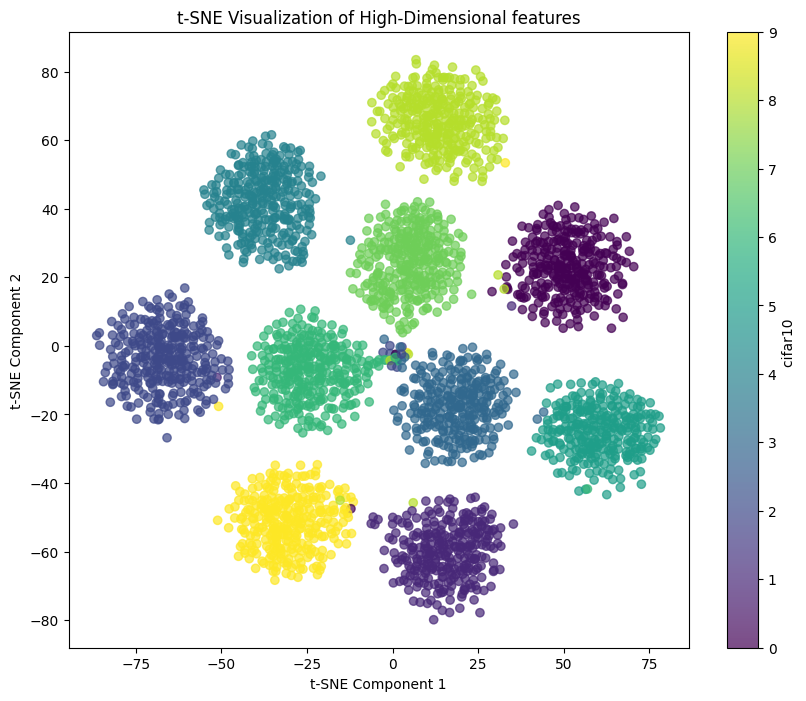

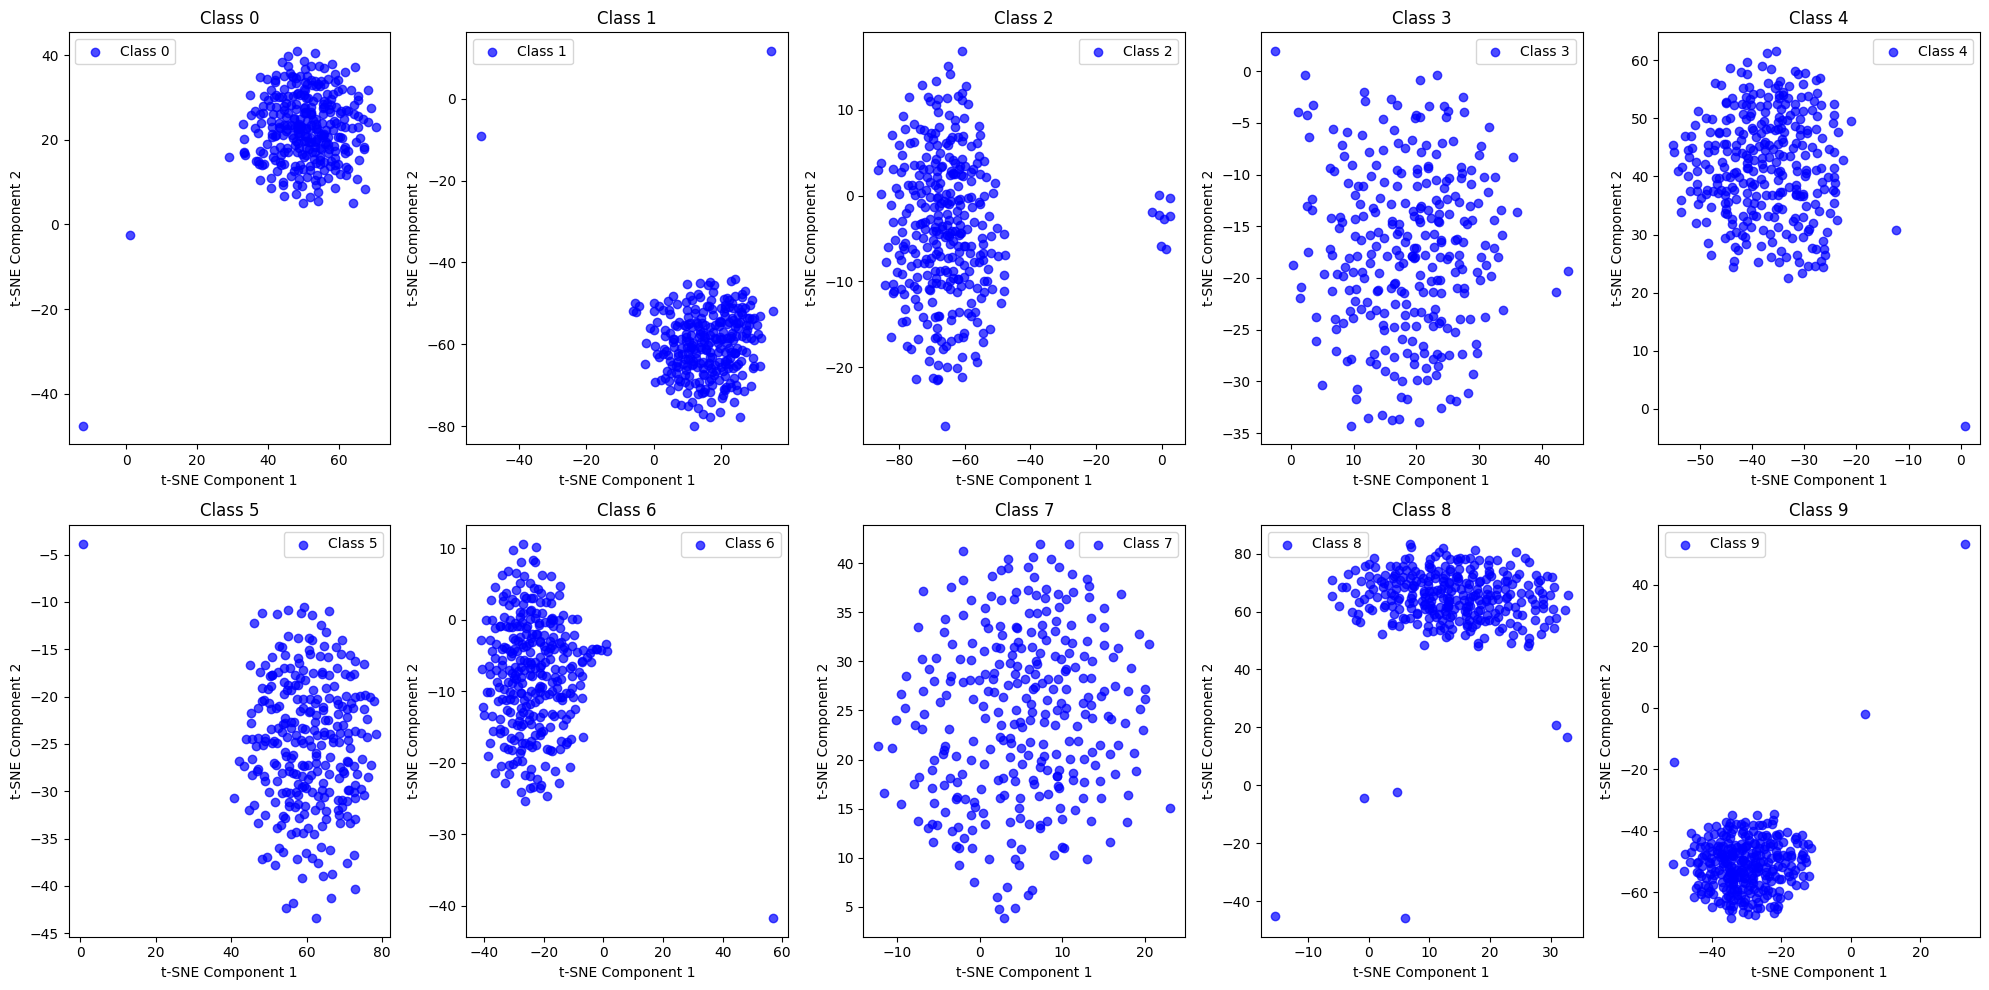

In [ ]:
import cudf
import numpy as np
import torch
from cuml.manifold import TSNE
import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE
import pandas as pd
# Initialize lists
features_all = []
labels_all = []

index = 4

# Feature extraction
for images, labels in train_loader:
    images = images.to(device)
    features_train = list(model.intermediate_forward(images, layer_index=index))
    for i in range(len(features_train)):
        features_train[i] = features_train[i].view(features_train[i].size(0), features_train[i].size(1), -1)
        features_train[i] = torch.mean(features_train[i].data, 2)  # Global average pooling
    features_all.extend(features_train)  # Append features for the batch
    labels_all.extend(labels.tolist())  # Append labels for the batch


features_tensor = torch.stack(features_all)
features_tensor = features_tensor.reshape(features_tensor.shape[0], -1)

if features_tensor.is_cuda:
    features_array = features_tensor.cpu().numpy()
else:
    features_array = features_tensor.numpy()
gdf = cudf.DataFrame(features_array)
# gdf = pd.DataFrame(features_array) 
# for OPgd
# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=50, n_iter=5000)
X_embedded = tsne.fit_transform(gdf)

# Debug step: Check shape of t-SNE output
print(f"Shape of X_embedded: {X_embedded.shape}")

# Debug step: Ensure lengths match before plotting
assert len(labels_all) == X_embedded.shape[0], "Mismatch between labels and t-SNE output."
labels_all = np.array(labels_all)

# Convert X_embedded (from cudf) back to numpy for compatibility with matplotlib
X_embedded = X_embedded.to_pandas().to_numpy()  


# Plot the t-SNE visualization
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels_all, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='cifar10 ')
plt.title(f't-SNE Visualization of High-Dimensional features')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()


import matplotlib.pyplot as plt
import numpy as np

# Number of classes to plot
num_classes = 10

# Create subplots
fig, axes = plt.subplots(2, 5, figsize=(20, 10))  # Adjust rows and columns as needed

for target_class in range(num_classes):
    # Filter the data for the target class
    class_mask = labels_all == target_class
    X_embedded_filtered = X_embedded[class_mask]
    
    # Get the corresponding axis for the subplot
    ax = axes[target_class // 5, target_class % 5]
    
    # Plot the t-SNE visualization for the specific class
    ax.scatter(X_embedded_filtered[:, 0], X_embedded_filtered[:, 1], 
               c='blue', alpha=0.7, label=f'Class {target_class}')
    ax.set_title(f'Class {target_class}')
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.legend()

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


## plot the 3d embedding/features of images in layer 1 in train_set 

In [18]:
import cudf
import numpy as np
import torch
# from cuml.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# Initialize lists
features_all = []
labels_all = []

index = 4

# Feature extraction
for images, labels in train_loader:
    images = images.to(device)
    features_train = list(model.intermediate_forward(images, layer_index=index))
    for i in range(len(features_train)):
        features_train[i] = features_train[i].view(features_train[i].size(0), features_train[i].size(1), -1)
        features_train[i] = torch.mean(features_train[i].data, 2)  # Global average pooling
    print(len(features_all)," <--------------------------")
    features_all.extend(features_train)  # Append features for the batch
    labels_all.extend(labels.tolist())  # Append labels for the batch
    if len(features_all) > 2000:
        print("break ho rha ", len(features_all), " ... ", len(labels_all))
        break


features_tensor = torch.stack(features_all)
 
gdf = pd.DataFrame(features_array) 
 
tsne = TSNE(n_components=3, random_state=42, perplexity=600, n_iter=5000)
X_embedded = tsne.fit_transform(gdf)
 
print(f"Shape of X_embedded: {X_embedded.shape}")
print(len(labels_all))
 
assert len(labels_all) == X_embedded.shape[0], "Mismatch between labels and t-SNE output."
labels_all = np.array(labels_all)
 




0  <--------------------------
100  <--------------------------
200  <--------------------------
300  <--------------------------
400  <--------------------------
500  <--------------------------
600  <--------------------------
700  <--------------------------
800  <--------------------------
900  <--------------------------
1000  <--------------------------
1100  <--------------------------
1200  <--------------------------
1300  <--------------------------
1400  <--------------------------
1500  <--------------------------
1600  <--------------------------
1700  <--------------------------
1800  <--------------------------
1900  <--------------------------
2000  <--------------------------
break ho rha  2100  ...  2100


/home/local/ASUAD/asing651/.conda/envs/rapids310/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Shape of X_embedded: (4788, 3)
2100


AssertionError: Mismatch between labels and t-SNE output.

In [20]:
import numpy as np
import torch
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.pyplot as plt


loaders = {
    "ID_train": train_loader,
    "deepfool": deepfool_test_loader,
    "cw" : cw_test_loader,
    "ID_test": test_loader,
    "pgd": pgd_test_loader,
    "fgsm": fgsm_test_loader,
    "aa": Autoattack_test_loader,
    "isun": isun_test_loader,
    "lsun":lsun_test_loader,
    "svhn": svhn_test_loader,
    "dtd": dtd_test_loader,
    "cifar100": cifar100_test_loader       
}
ood = ["isun","svhn","dtd","lsun","cifar100"]
adv = ["cw","pgd","fgsm","deepfool","aa"]
 
 
features_all = []
labels_all = []
index = 3
 
with torch.no_grad():
    for item in loaders:
        loader = loaders[item]

        for images, labels in loader:
            images = images.to(device)
     
            features_train = model.intermediate_forward(images, layer_index=index)
        
            features_train = features_train.view(features_train.size(0), features_train.size(1), -1)
            features_train = torch.mean(features_train, 2)   
             
            for j in range(features_train.size(0)):
                features_all.append(features_train[j]) 
            if item == 'ID_train' or item == 'ID_test':
                labels_all.extend(labels.tolist())
            elif item in ood:
                labels_all.extend([(100) for i in range(len(labels))])
            else:
                print("200 wala -> adv = ", item)
                labels_all.extend([(200) for i in range(len(labels))])
            if len(features_all) > 2000:
                print("break ho rha ", len(features_all), " ... ", len(labels_all))
                break

# Stack features into a tensor
features_tensor = torch.stack(features_all)  # Shape: (n_samples, num_filters)
# Convert to DataFrame
gdf = pd.DataFrame(features_tensor.cpu().numpy())

# Apply t-SNE
tsne = TSNE(n_components=3, random_state=42, perplexity=50, n_iter=5000)
X_embedded = tsne.fit_transform(gdf)

print(f"Shape of X_embedded: {X_embedded.shape}")
print(len(labels_all))

# Verify lengths match
assert len(labels_all) == X_embedded.shape[0], "Mismatch between labels and t-SNE output."
labels_all = np.array(labels_all)

# Plotting code can follow here

break ho rha  2100  ...  2100
200 wala -> adv =  deepfool
break ho rha  2200  ...  2200
200 wala -> adv =  cw
break ho rha  2300  ...  2300
break ho rha  2400  ...  2400
200 wala -> adv =  pgd
break ho rha  2500  ...  2500
200 wala -> adv =  fgsm
break ho rha  2600  ...  2600
200 wala -> adv =  aa
break ho rha  2700  ...  2700
break ho rha  2800  ...  2800
break ho rha  2900  ...  2900
break ho rha  3000  ...  3000
break ho rha  3100  ...  3100
break ho rha  3200  ...  3200


/home/local/ASUAD/asing651/.conda/envs/rapids310/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Shape of X_embedded: (3200, 3)
3200


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Define multiple viewing angles
angles = [
    {'elev': 30, 'azim': 45, 'name': 'angle_30_45'},
    {'elev': 0, 'azim': 0, 'name': 'side_x'},
    {'elev': 90, 'azim': 0, 'name': 'top_down'},
    {'elev': 30, 'azim': 135, 'name': 'angle_30_135'}
]

for angle in angles:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    mask_other = ~np.isin(labels_all, [100, 200])
    X_filtered_other = X_embedded[mask_other]
    labels_filtered_other = labels_all[mask_other]
    scatter_other = ax.scatter(
        X_filtered_other[:, 0], X_filtered_other[:, 1], X_filtered_other[:, 2],
        c=labels_filtered_other, cmap='Blues', alpha=0.1, label='Other Labels'
    )

    mask_100 = labels_all == 100
    X_label_100 = X_embedded[mask_100]
    labels_label_100 = labels_all[mask_100]
    n_samples_100 = min(50, len(X_label_100))
    if n_samples_100 > 0:
        indices_100 = np.random.choice(len(X_label_100), size=n_samples_100, replace=False)
        X_label_100_sampled = X_label_100[indices_100]
        labels_label_100_sampled = labels_label_100[indices_100]
        scatter_100 = ax.scatter(
            X_label_100_sampled[:, 0], X_label_100_sampled[:, 1], X_label_100_sampled[:, 2],
            c=labels_label_100_sampled, cmap='Oranges', alpha=0.7, label='Label 100 (50 points)'
        )
        cbar_100 = plt.colorbar(scatter_100, ax=ax, shrink=0.5, aspect=10, pad=0.12)
        cbar_100.set_label('Label 100')
    else:
        print("No points available for label 100.")

    mask_200 = labels_all == 200
    X_label_200 = X_embedded[mask_200]
    labels_label_200 = labels_all[mask_200]
    n_samples_200 = min(50, len(X_label_200))
    if n_samples_200 > 0:
        indices_200 = np.random.choice(len(X_label_200), size=n_samples_200, replace=False)
        X_label_200_sampled = X_label_200[indices_200]
        labels_label_200_sampled = labels_label_200[indices_200]
        scatter_200 = ax.scatter(
            X_label_200_sampled[:, 0], X_label_200_sampled[:, 1], X_label_200_sampled[:, 2],
            c=labels_label_200_sampled, cmap='Greens', alpha=0.7, label='Label 200 (50 points)'
        )
        cbar_200 = plt.colorbar(scatter_200, ax=ax, shrink=0.5, aspect=10, pad=0.18)
        cbar_200.set_label('Label 200')
    else:
        print("No points available for label 200.")

    cbar_other = plt.colorbar(scatter_other, ax=ax, shrink=0.5, aspect=10, pad=0.02)
    cbar_other.set_label('Other Labels')

    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.set_zlabel('t-SNE Component 3')
    ax.set_title(f't-SNE Visualization of High-Dimensional Features for {item}')
    ax.view_init(elev=angle['elev'], azim=angle['azim'])
    ax.legend()
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')

    plt.savefig(f'tsne_plot_{angle["name"]}.png')
    plt.close(fig)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
a =[(100) for i in range(10)]
print(a)

[100, 100, 100, 100, 100, 100, 100, 100, 100, 100]


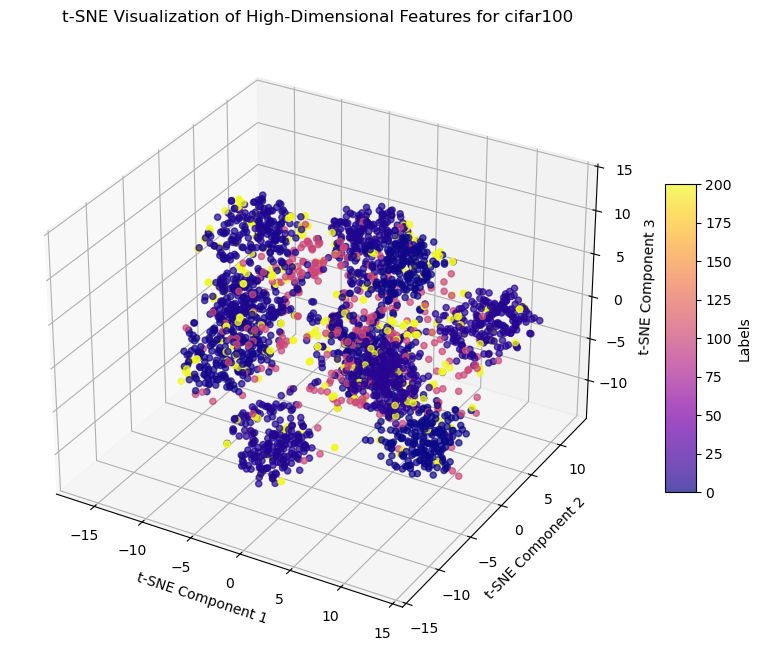

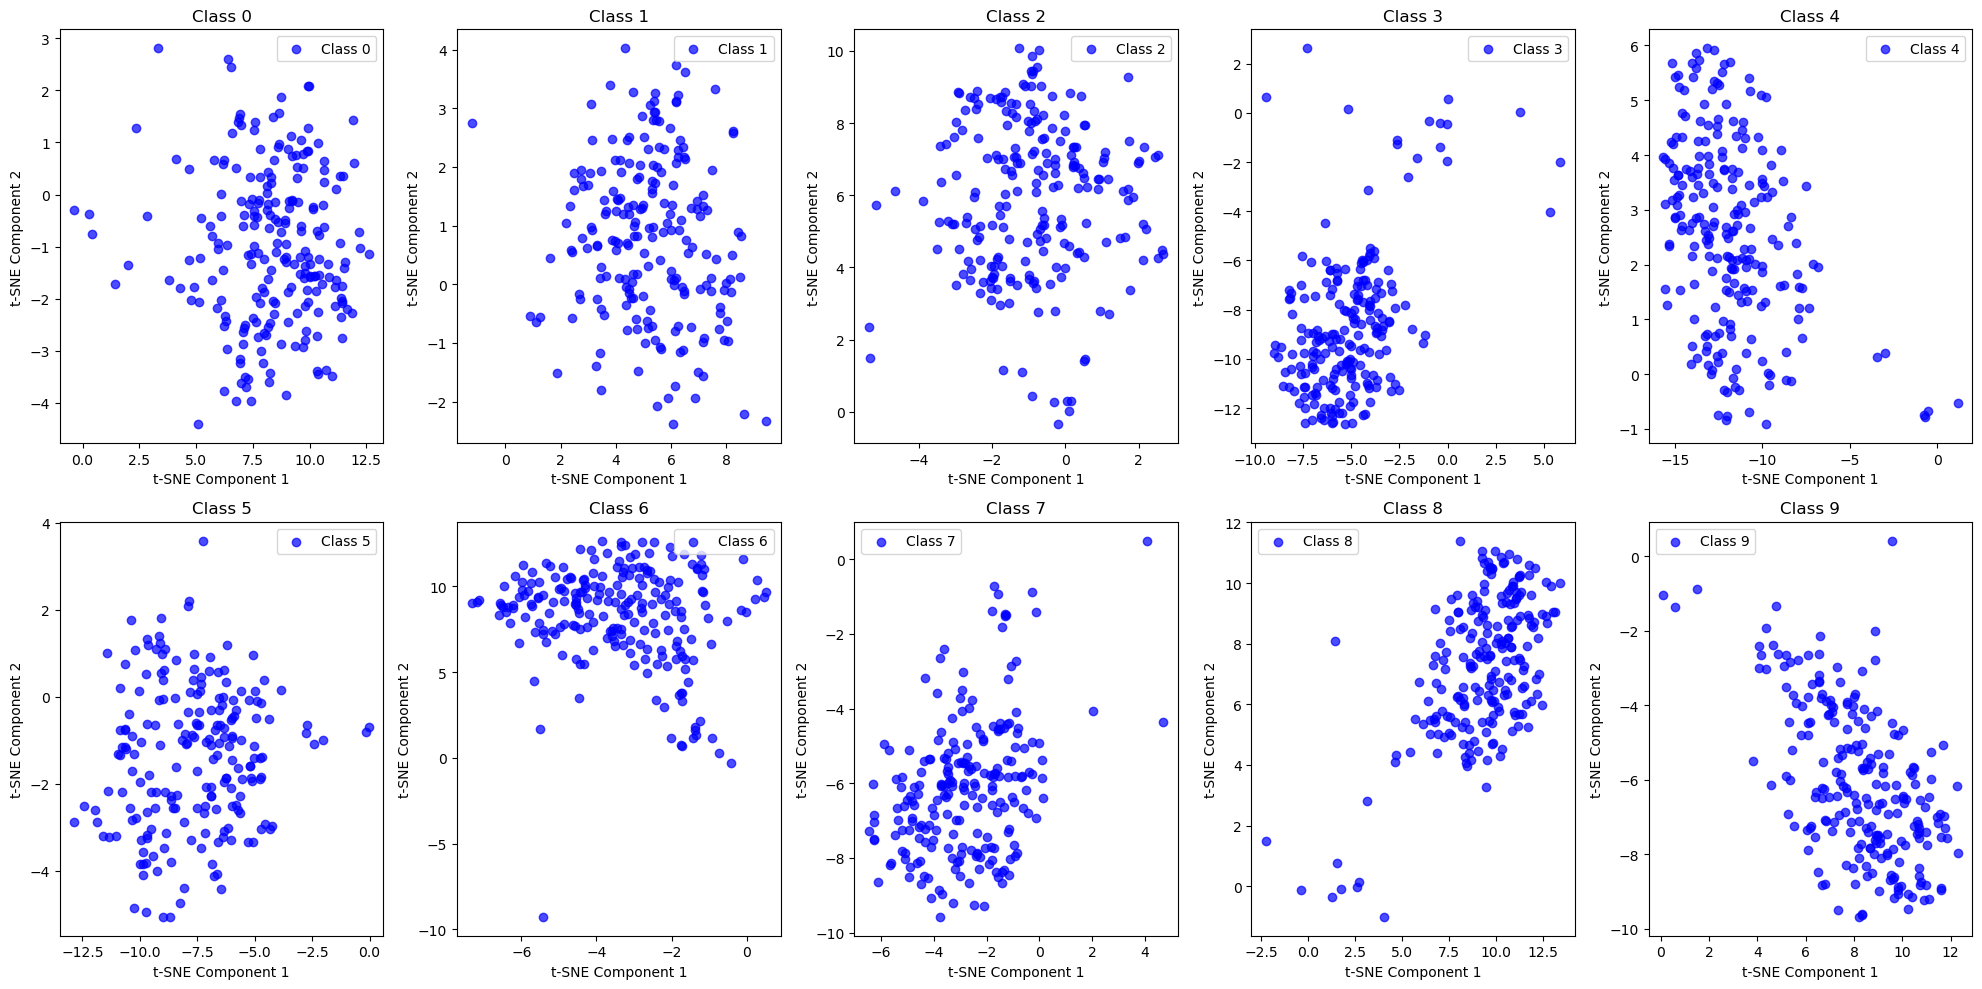

In [4]:
# Create a figure and 3D axis
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(
    X_embedded[:, 0], 
    X_embedded[:, 1], 
    X_embedded[:, 2],
    c=labels_all,       # Use labels for coloring
    cmap='plasma',     # Colormap
    alpha=0.7           # Transparency
)

# Add color bar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Labels')

# Set axis labels
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')

# Set title
ax.set_title(f't-SNE Visualization of High-Dimensional Features for {item}')

# Display the plot
plt.show()
# Number of classes to plot
num_classes = 10

# Create subplots
fig, axes = plt.subplots(2, 5, figsize=(20, 10))  # Adjust rows and columns as needed

for target_class in range(num_classes):
    # Filter the data for the target class
    class_mask = labels_all == target_class
    X_embedded_filtered = X_embedded[class_mask]
    
    # Get the corresponding axis for the subplot
    ax = axes[target_class // 5, target_class % 5]
    
    # Plot the t-SNE visualization for the specific class
    ax.scatter(X_embedded_filtered[:, 0], X_embedded_filtered[:, 1], 
               c='blue', alpha=0.7, label=f'Class {target_class}')
    ax.set_title(f'Class {target_class}')
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.legend()

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

## make the plots similarly for different  attacks

 Eval the pgd dataset!

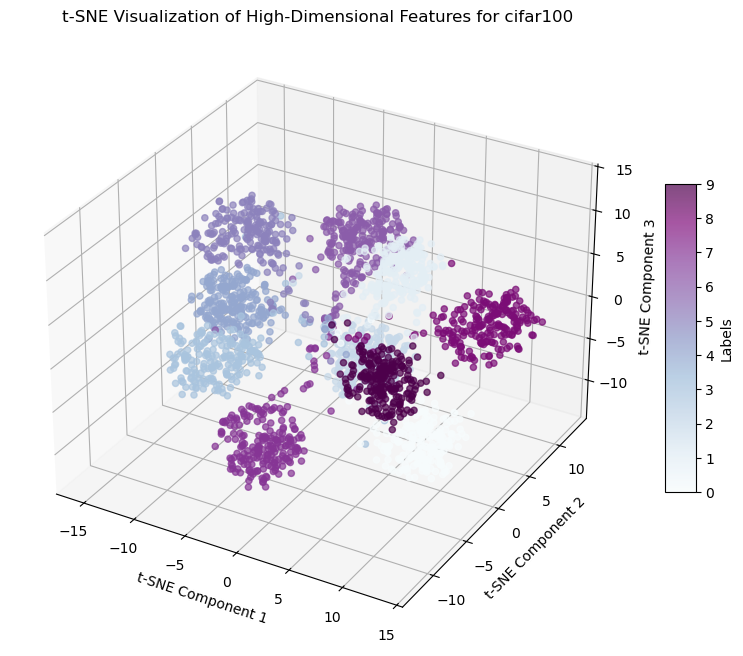

In [5]:
import numpy as np

# Create a figure and 3D axis
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Filter out labels 100 and 200
mask = ~np.isin(labels_all, [100, 200])  # Create a boolean mask for labels not equal to 100 or 200
X_filtered = X_embedded[mask]             # Filter X_embedded
labels_filtered = labels_all[mask]        # Filter labels_all

# Scatter plot with filtered data
scatter = ax.scatter(
    X_filtered[:, 0], 
    X_filtered[:, 1], 
    X_filtered[:, 2],
    c=labels_filtered,  # Use filtered labels for coloring
    cmap='BuPu',      # Colormap
    alpha=0.7           # Transparency
)

# Add color bar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Labels')

# Set axis labels
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')

# Set title
ax.set_title(f't-SNE Visualization of High-Dimensional Features for {item}')

# Display the plot
plt.show()

KeyboardInterrupt: 

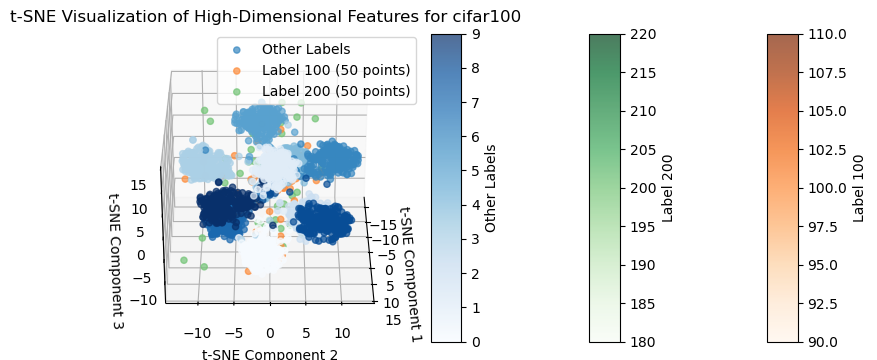

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Create a figure and 3D axis
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Filter and plot data (same as before)
mask_other = ~np.isin(labels_all, [100, 200])
X_filtered_other = X_embedded[mask_other]
labels_filtered_other = labels_all[mask_other]
scatter_other = ax.scatter(
    X_filtered_other[:, 0], X_filtered_other[:, 1], X_filtered_other[:, 2],
    c=labels_filtered_other, cmap='Blues', alpha=0.7, label='Other Labels'
)

mask_100 = labels_all == 100
X_label_100 = X_embedded[mask_100]
labels_label_100 = labels_all[mask_100]
n_samples_100 = min(50, len(X_label_100))
if n_samples_100 > 0:
    indices_100 = np.random.choice(len(X_label_100), size=n_samples_100, replace=False)
    X_label_100_sampled = X_label_100[indices_100]
    labels_label_100_sampled = labels_label_100[indices_100]
    scatter_100 = ax.scatter(
        X_label_100_sampled[:, 0], X_label_100_sampled[:, 1], X_label_100_sampled[:, 2],
        c=labels_label_100_sampled, cmap='Oranges', alpha=0.7, label='Label 100 (50 points)'
    )
    cbar_100 = plt.colorbar(scatter_100, ax=ax, shrink=0.5, aspect=10, pad=0.12)
    cbar_100.set_label('Label 100')
else:
    print("No points available for label 100.")

mask_200 = labels_all == 200
X_label_200 = X_embedded[mask_200]
labels_label_200 = labels_all[mask_200]
n_samples_200 = min(50, len(X_label_200))
if n_samples_200 > 0:
    indices_200 = np.random.choice(len(X_label_200), size=n_samples_200, replace=False)
    X_label_200_sampled = X_label_200[indices_200]
    labels_label_200_sampled = labels_label_200[indices_200]
    scatter_200 = ax.scatter(
        X_label_200_sampled[:, 0], X_label_100_sampled[:, 1], X_label_200_sampled[:, 2],
        c=labels_label_200_sampled, cmap='Greens', alpha=0.7, label='Label 200 (50 points)'
    )
    cbar_200 = plt.colorbar(scatter_200, ax=ax, shrink=0.5, aspect=10, pad=0.18)
    cbar_200.set_label('Label 200')
else:
    print("No points available for label 200.")

cbar_other = plt.colorbar(scatter_other, ax=ax, shrink=0.5, aspect=10, pad=0.02)
cbar_other.set_label('Other Labels')

ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')
ax.set_title(f't-SNE Visualization of High-Dimensional Features for {item}')
ax.legend()
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Animation function
def update(frame):
    ax.view_init(elev=30, azim=frame)  # Rotate azimuth from 0 to 360
    return ax,

# Create animation
ani = FuncAnimation(fig, update, frames=np.arange(0, 360, 2), interval=50)
ani.save('tsne_rotation.gif', writer='pillow')

plt.close(fig)

In [11]:
# # Set the model to evaluation mode
# model.eval()

# # Initialize variables to track correct predictions and total samples
# correct = 0
# total = 0
# pred = {}
# # Disable gradient calculation
# with torch.no_grad():
#     for images, labels in pgd_test_loader:
#         # Move images and labels to the appropriate device (e.g., GPU)
#         images = images.to(device)
#         labels = labels.to(device)
        
#         # Forward pass: get model predictions
#         outputs = model(images)
        
#         # Get the predicted class (the class with the highest probability)
#         _, predicted = torch.max(outputs, 1)
#         p= predicted.item()
#         if p in pred:
#             pred[p] +=1
#         else:
#             pred[p] = 1
#         # Update total and correct counts
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()

# # Calculate accuracy
# accuracy = 100 * correct / total
# print(f'Accuracy on PGD Test Loader: {accuracy:.2f}%')

Accuracy on PGD Test Loader: 26.38%


/home/local/ASUAD/asing651/.conda/envs/rapids_env/lib/python3.10/site-packages/cuml/internals/api_decorators.py:382: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return init_func(self, *args, **filtered_kwargs)


[W] [20:27:53.765545] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
Shape of X_embedded: (10000, 2)


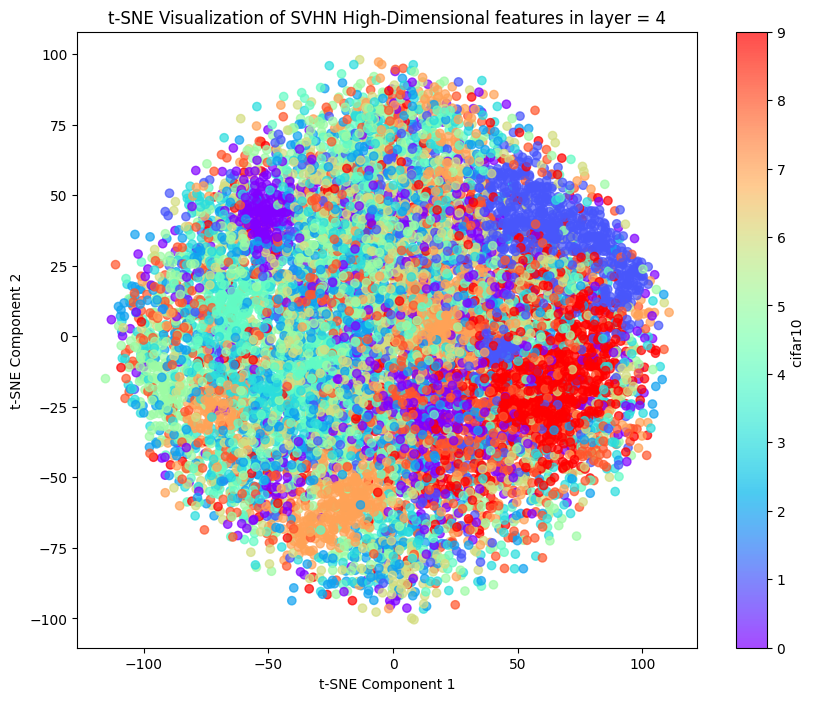

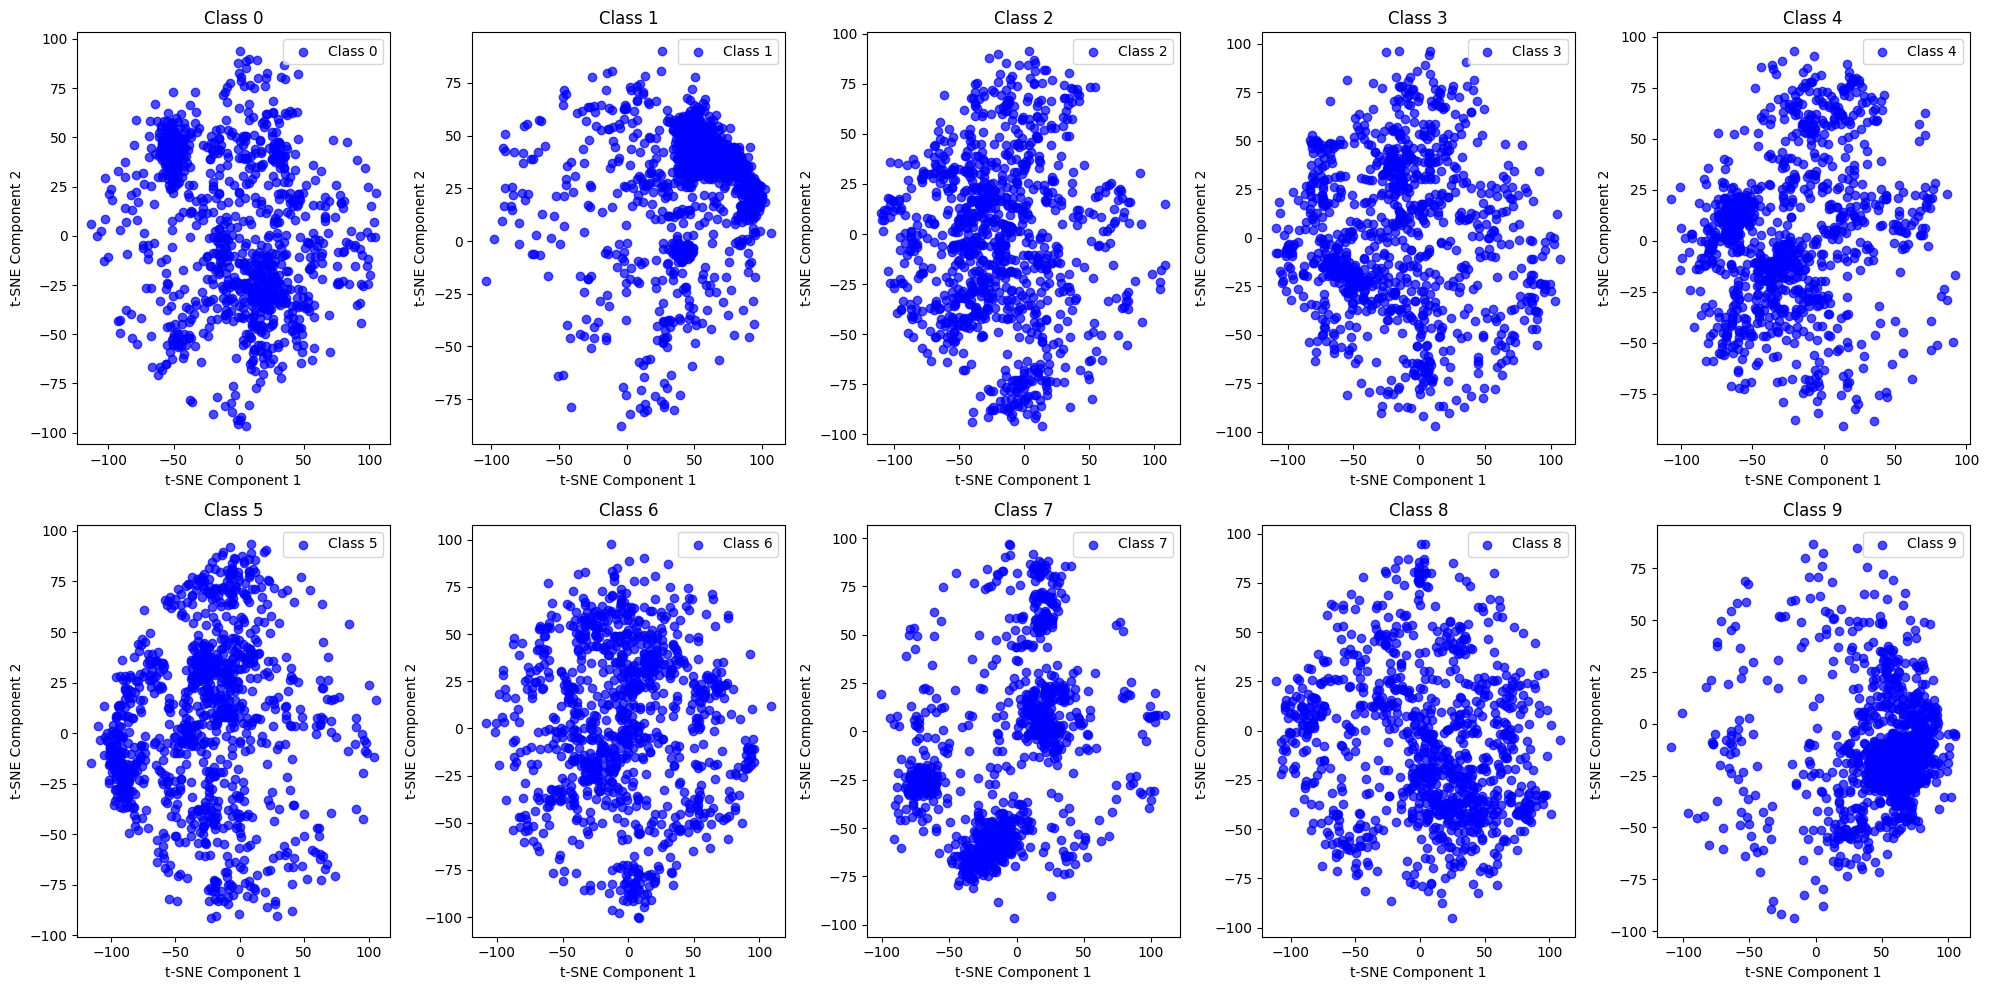

In [ ]:
import cudf
import numpy as np
import torch
from cuml.manifold import TSNE
import matplotlib.pyplot as plt


features_all = []
labels_all = []

index = 4

 
for images, labels in test_loader:
    images = images.to(device)
    features_train = list(model.intermediate_forward(images, layer_index=index))
    for i in range(len(features_train)):
        features_train[i] = features_train[i].view(features_train[i].size(0), features_train[i].size(1), -1)
        features_train[i] = torch.mean(features_train[i].data, 2)   
    features_all.extend(features_train)   
    labels_all.extend(labels.tolist()) 



features_tensor = torch.stack(features_all)
features_tensor = features_tensor.reshape(features_tensor.shape[0], -1)

if features_tensor.is_cuda:
    features_array = features_tensor.cpu().numpy()
else:
    features_array = features_tensor.numpy()
gdf = cudf.DataFrame(features_array)

 
# tsne = TSNE(n_components=2, random_state=42, perplexity=1000, n_iter=5000)
tsne = TSNE(n_components=2, random_state=42, perplexity=50, n_iter=5000)
# tsne = TSNE(n_components=2, perplexity=500, learning_rate=200,auto_iter=True,early_exaggeration=12, init='random', random_state=42)
X_embedded = tsne.fit_transform(gdf)
 
print(f"Shape of X_embedded: {X_embedded.shape}")
 
assert len(labels_all) == X_embedded.shape[0], "Mismatch between labels and t-SNE output."
labels_all = np.array(labels_all)
 
X_embedded = X_embedded.to_pandas().to_numpy()
 
df = cudf.DataFrame(X_embedded, columns=['feature1', 'feature2'])
df['labels'] = labels_all

# # commnt below code 
# z_scores = cudf.DataFrame()

# for col in ['feature1', 'feature2']:
#     mean = df[col].mean()  
#     std = df[col].std()    
#     z_scores[col] = (df[col] - mean) / std 
# threshold = 3

# outlier_rows = (z_scores.abs() > threshold).any(axis=1)

# df = df[~outlier_rows]




data = df[['feature1', 'feature2']].to_pandas().values   
labels = df['labels'].to_pandas().values   


plt.figure(figsize=(10, 8))
scatter = plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='rainbow', alpha=0.7)
plt.colorbar(scatter, label='cifar10 ')
plt.title(f't-SNE Visualization of SVHN High-Dimensional features in layer = {index}')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.show()


import matplotlib.pyplot as plt
import numpy as np

 
num_classes = 10

 
fig, axes = plt.subplots(2, 5, figsize=(20, 10))   

for target_class in range(num_classes):
    # Filter the data for the target class
    class_mask = labels_all == target_class
    X_embedded_filtered = X_embedded[class_mask]
    mean_embedding = np.mean(X_embedded_filtered, axis=0)  
    # Get the corresponding axis for the subplot
    ax = axes[target_class // 5, target_class % 5]
    
    # Plot the t-SNE visualization for the specific class
    ax.scatter(X_embedded_filtered[:, 0], X_embedded_filtered[:, 1], 
               c='blue', alpha=0.7, label=f'Class {target_class}')
    ax.scatter(mean_embedding[0], mean_embedding[1], 
               c='red', marker='X', s=100, label='Mean')
    ax.set_title(f'Class {target_class}')
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.legend()

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


#

## plot all the features in the same plot

/home/local/ASUAD/asing651/.conda/envs/rapids_env/lib/python3.10/site-packages/cuml/internals/api_decorators.py:382: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return init_func(self, *args, **filtered_kwargs)


[W] [20:34:49.134115] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
Shape of X_embedded: (84957, 2)


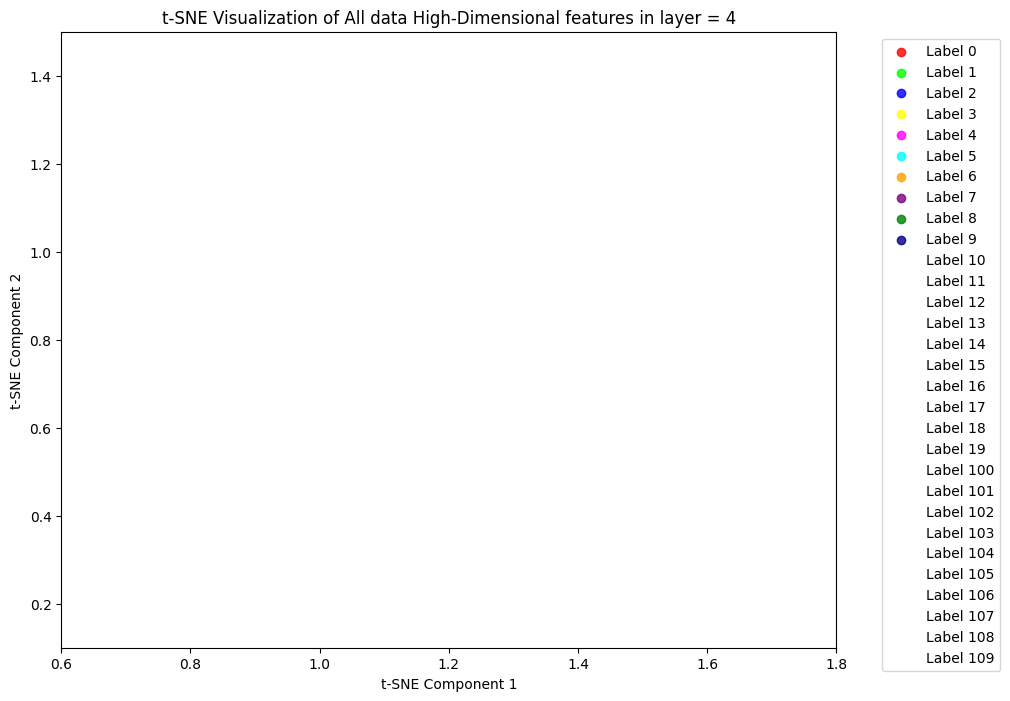

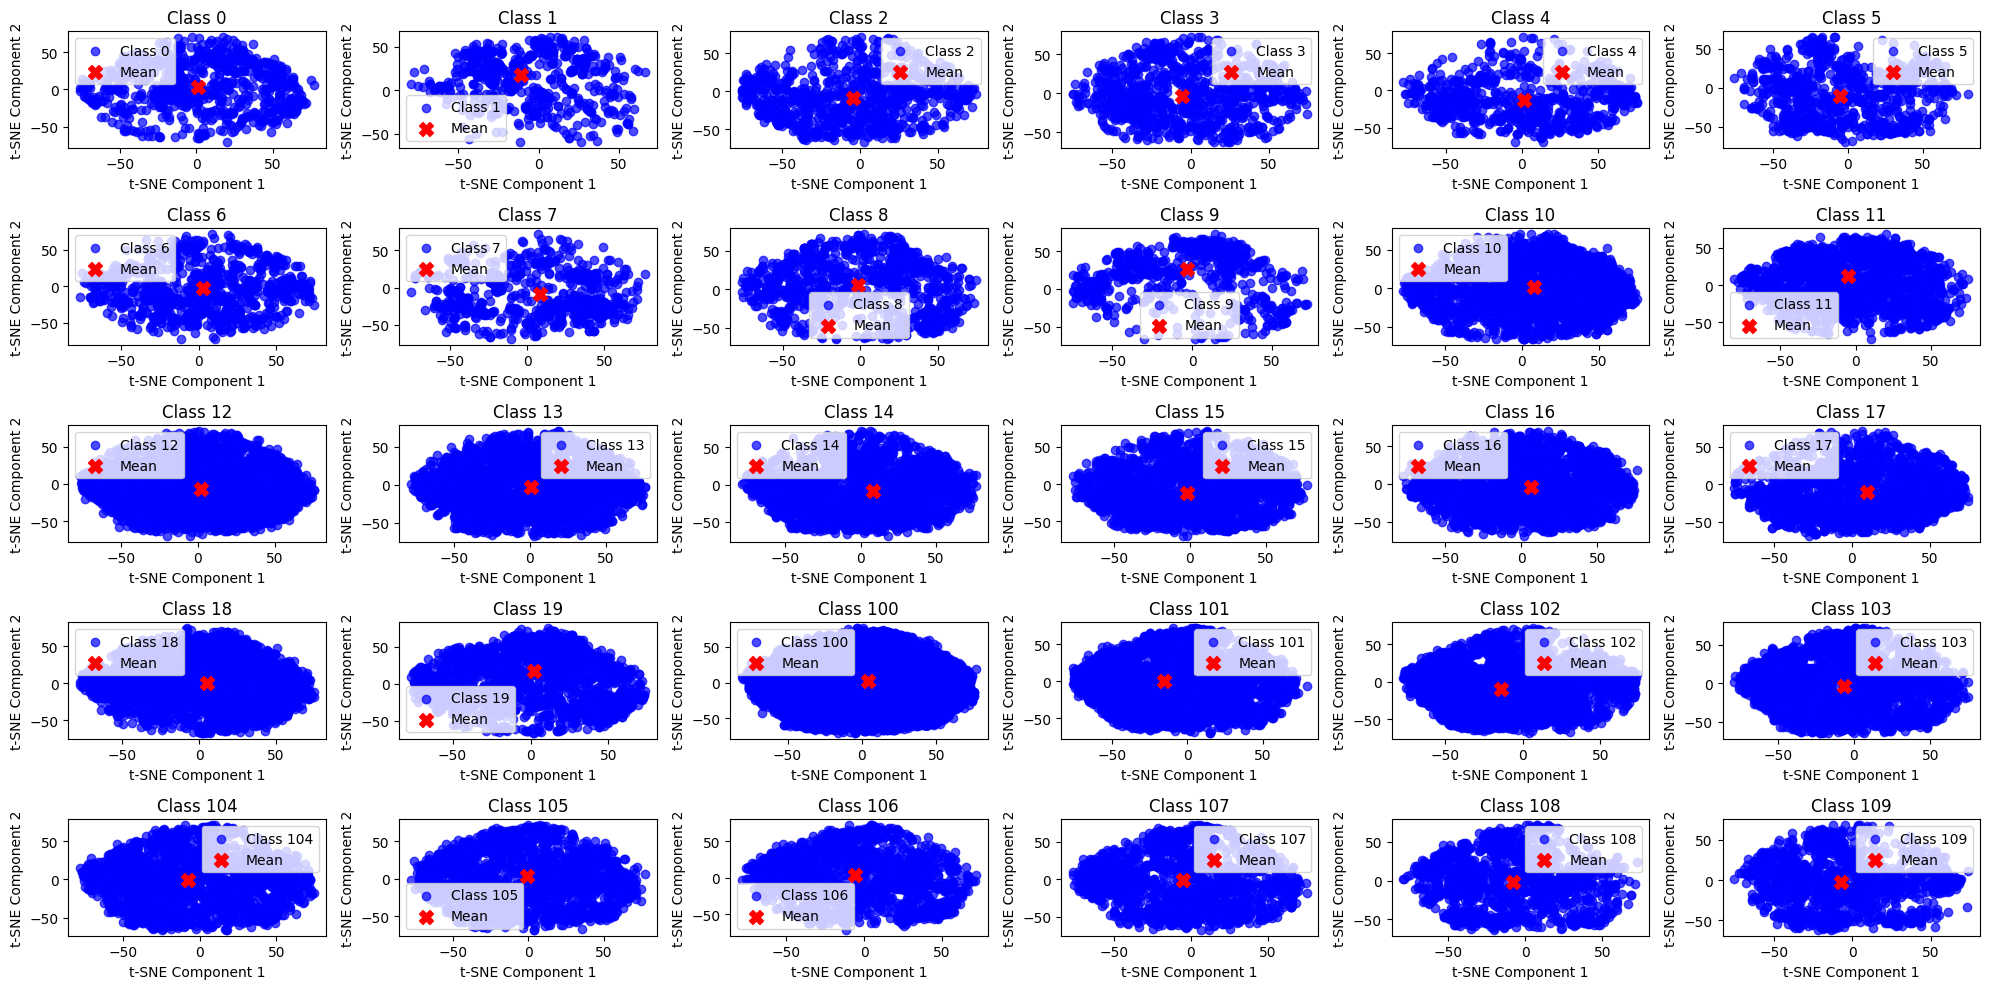

In [13]:
import cudf
import numpy as np
import torch
from cuml.manifold import TSNE
import matplotlib.pyplot as plt

# Initialize lists
features_all = []
labels_all = []

index = 4
'''
id data label 0 -9
adv attacked data label 10 -19
ood data label 100- 109

'''
# Feature extraction for all the datasets
def featureextract  (testloader,model,device,features_all,labels_all,flag, index):
    j= 0 
    lim = 2500000
    for images, labels in testloader:
        j += 1
        images = images.to(device)
        if flag == 1:
            labels += 100
            # lim = 100
        if flag == 0 :
            labels += 10
            # lim = 100
        features_train = list(model.intermediate_forward(images, layer_index=index))
        for i in range(len(features_train)):
            features_train[i] = features_train[i].view(features_train[i].size(0), features_train[i].size(1), -1)
            features_train[i] = torch.mean(features_train[i].data, 2)  # Global average pooling
        features_all.extend(features_train)  # Append features for the batch
        labels_all.extend(labels.tolist())  # Append labels for the batch
        if j > lim:
            break 



# LoaderList = [pgd_test_loader, test_loader,fgsm_test_loader, Autoattack_test_loader,svhn_test_loader,isun_test_loader,lsun_test_loader]

adv_loaders = [pgd_test_loader, fgsm_test_loader, Autoattack_test_loader]
ood_loaders = [svhn_test_loader, isun_test_loader, lsun_test_loader]


# flag is to denote testset. and change its labels                                          
flag = 0
for loader in adv_loaders:
    featureextract(loader,model,device,features_all,labels_all,0,index)
for loader in ood_loaders:
    featureextract(loader,model,device,features_all,labels_all,1,index)

featureextract(test_loader,model,device,features_all,labels_all,-1,index)

features_tensor = torch.stack(features_all)
features_tensor = features_tensor.reshape(features_tensor.shape[0], -1)

if features_tensor.is_cuda:
    features_array = features_tensor.cpu().numpy()
else:
    features_array = features_tensor.numpy()
gdf = cudf.DataFrame(features_array)
 
tsne = TSNE(n_components=2, random_state=42, perplexity=50, n_iter=5000)
X_embedded = tsne.fit_transform(gdf)
 
print(f"Shape of X_embedded: {X_embedded.shape}")
 
assert len(labels_all) == X_embedded.shape[0], "Mismatch between labels and t-SNE output."
labels_all = np.array(labels_all)
 
X_embedded = X_embedded.to_pandas().to_numpy()
 
df = cudf.DataFrame(X_embedded, columns=['feature1', 'feature2'])
df['labels'] = labels_all

# ## commnt below code 
# z_scores = cudf.DataFrame()

# for col in ['feature1', 'feature2']:
#     mean = df[col].mean()  
#     std = df[col].std()    
#     z_scores[col] = (df[col] - mean) / std 
# threshold = 3

# outlier_rows = (z_scores.abs() > threshold).any(axis=1)

# df = df[~outlier_rows]



# Assuming df is your DataFrame and it has been defined earlier
data = df[['feature1', 'feature2']].to_pandas().values   
labels = df['labels'].to_pandas().values   

plt.figure(figsize=(10, 8))

# Define vibrant colors for labels 0-9
vibrant_colors = [
    '#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF', '#00FFFF', 
    '#FFA500', '#800080', '#008000', '#000080'
]

# Create a colormap for unique colors for each label
color_mapping = {
    '10-19': 'blue',    # Single color for labels 10-19
    '0-9': vibrant_colors,  # List of vibrant colors for labels 0-9
    '100-109': 'red'    # Single color for labels 100-109
}

# Define alpha mapping for each label range
alpha_mapping = {
    '10-19': np.linspace(0.0, 0.0, 10),  # 10 alpha values for labels 10-19
    '0-9': np.linspace(0.8, 0.8, 10),    # 10 alpha values for labels 0-9
    '100-109': np.linspace(0.0,0.0, 10) # 10 alpha values for labels 100-109
}

# Plot each label with its specific color and alpha value
for label in np.unique(labels):
    mask = labels == label
    
    # Determine which range the label belongs to
    if 10 <= label <= 19:
        color = color_mapping['10-19']
        alpha = alpha_mapping['10-19'][label - 10]  # Get alpha value for this label
    elif 0 <= label <= 9:
        color = color_mapping['0-9'][label]  # Get vibrant color for this label
        alpha = alpha_mapping['0-9'][label]  # Get alpha value for this label
    elif 100 <= label <= 109:
        color = color_mapping['100-109']
        alpha = alpha_mapping['100-109'][label - 100]  # Get alpha value for this label
    else:
        continue  # Skip labels outside the specified ranges
    
    plt.scatter(
        data[mask, 0], 
        data[mask, 1], 
        c=color,  
        alpha=alpha,  # Specific alpha for the label
        label=f'Label {label}'
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.title(f't-SNE Visualization of All data High-Dimensional features in layer = {index}')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.xlim(0.6,1.8)
plt.ylim(0.1,1.5)

plt.show()


import matplotlib.pyplot as plt
import numpy as np

# Number of classes to plot
classes =  np.unique(labels)

# Create subplots
fig, axes = plt.subplots(5, 6, figsize=(20, 10))  # Adjust rows and columns as needed
axes = axes.flatten()
p = 0
for target_class in classes:
    
    # Filter the data for the target class
    class_mask = labels_all == target_class
    X_embedded_filtered = X_embedded[class_mask]
    
    # Get the corresponding axis for the subplot
    ax = axes[p]
    p += 1
    mean_embedding = np.mean(X_embedded_filtered, axis=0)
    # Plot the t-SNE visualization for the specific class
    ax.scatter(X_embedded_filtered[:, 0], X_embedded_filtered[:, 1], 
               c='blue', alpha=0.7, label=f'Class {target_class}')
    ax.scatter(mean_embedding[0], mean_embedding[1], 
               c='red', marker='X', s=100, label='Mean')
    ax.set_title(f'Class {target_class}')
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.legend()

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

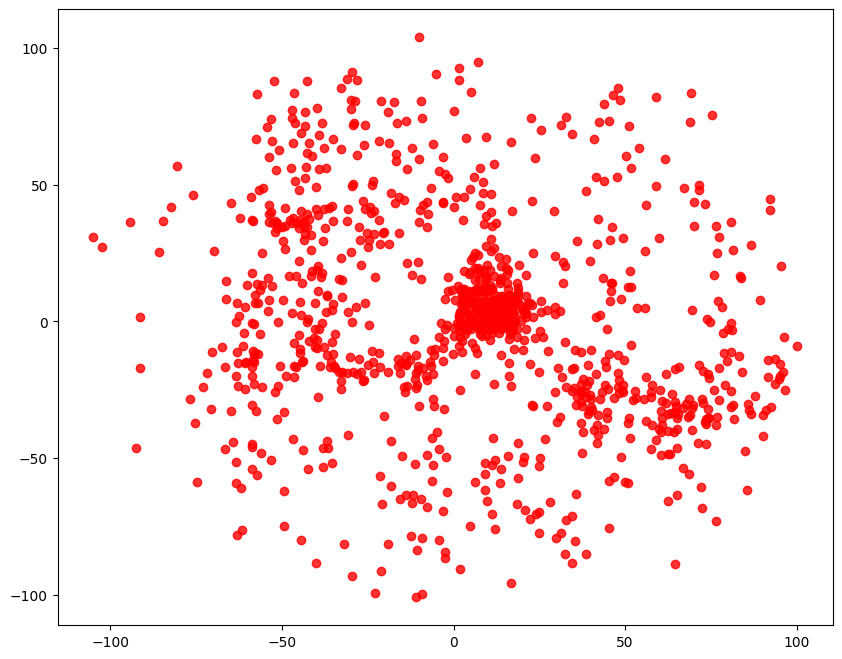

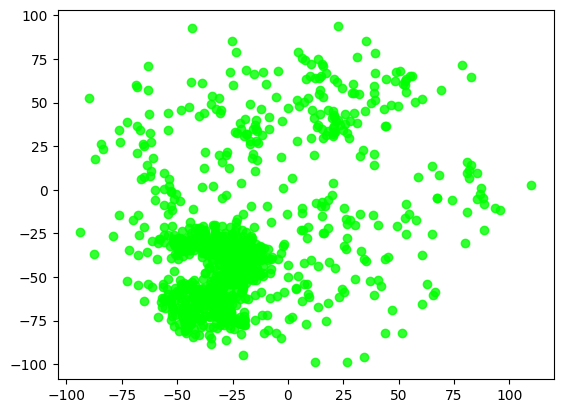

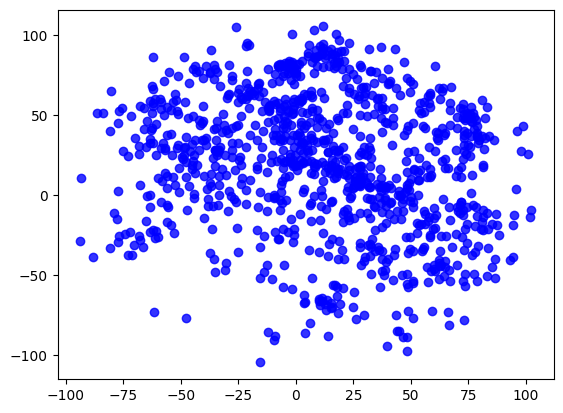

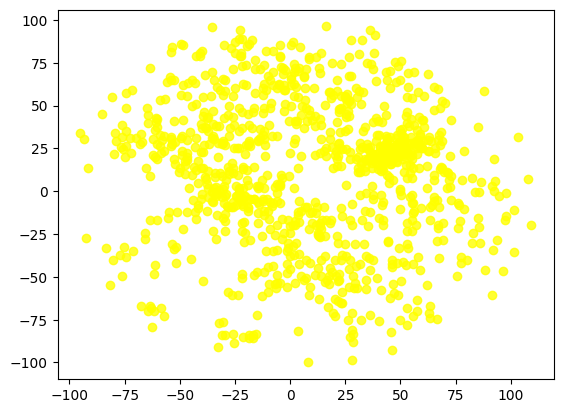

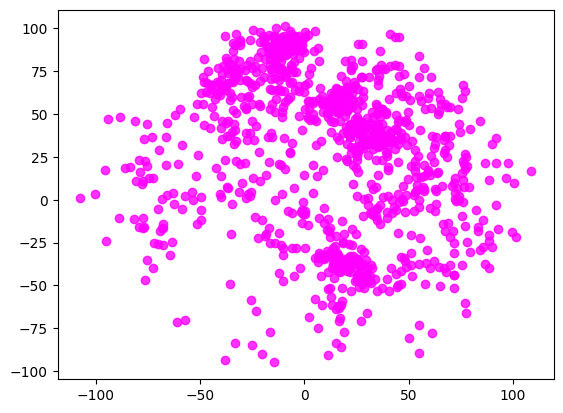

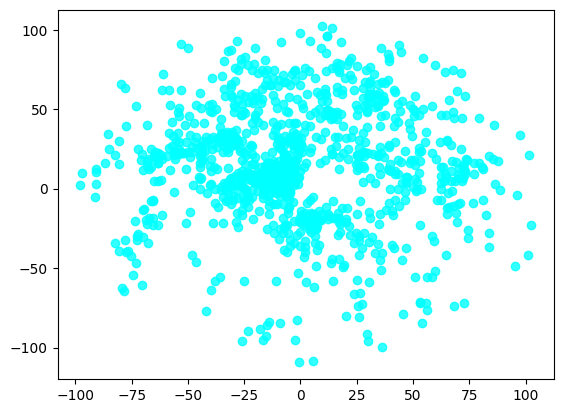

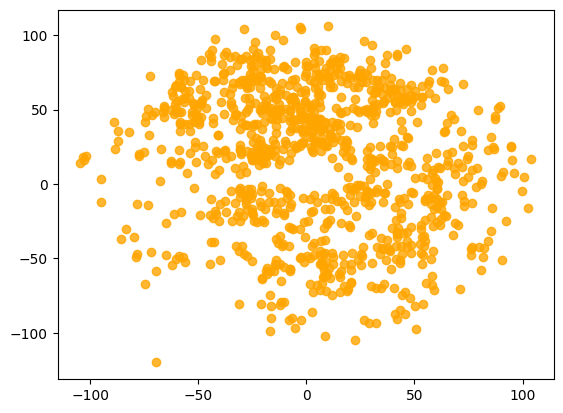

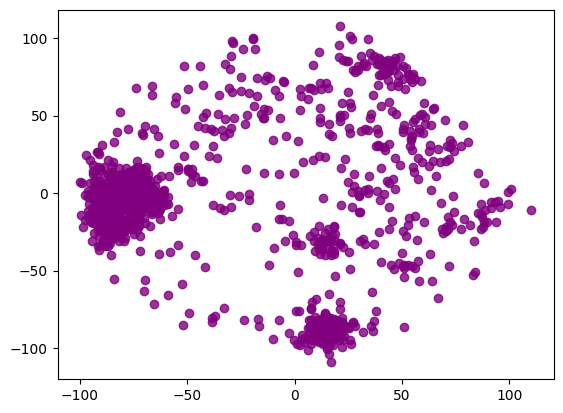

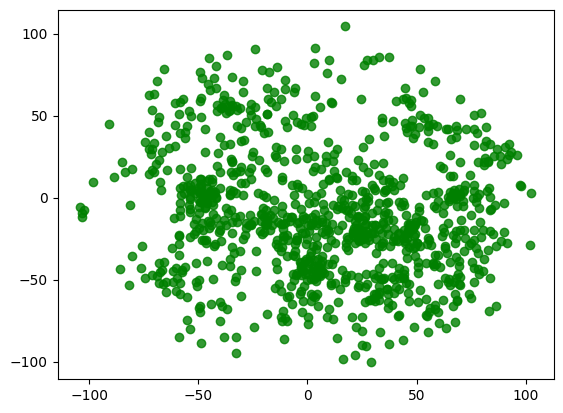

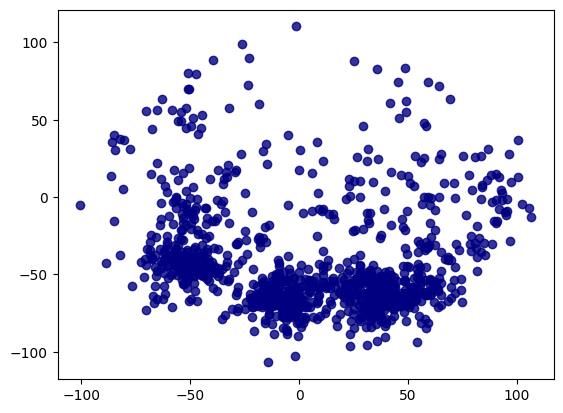

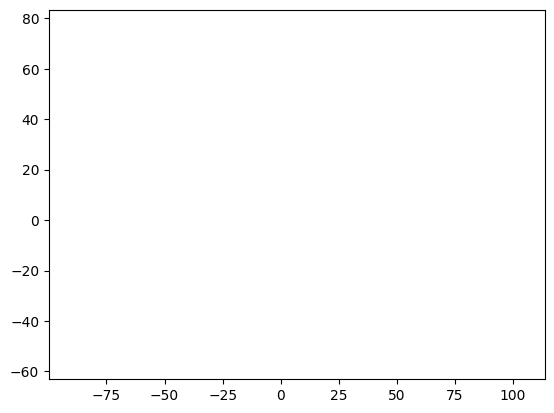

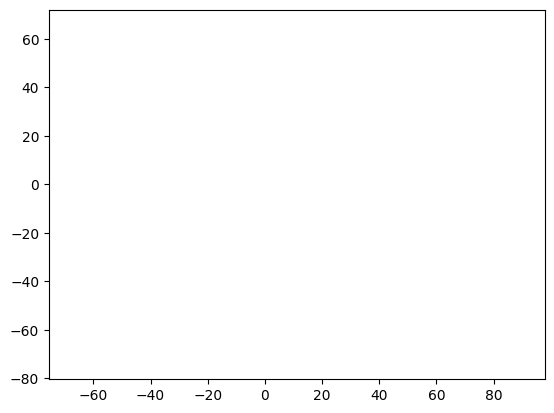

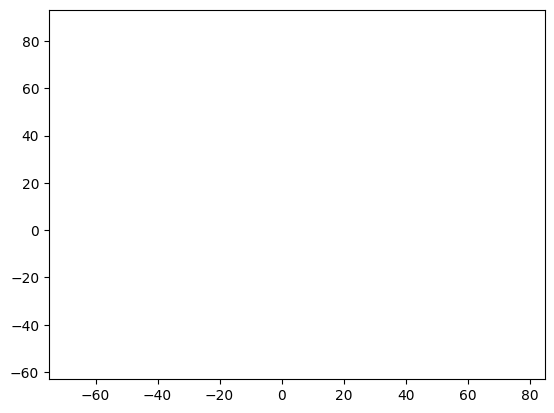

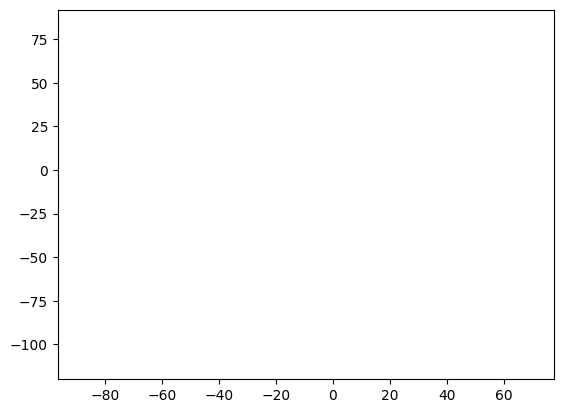

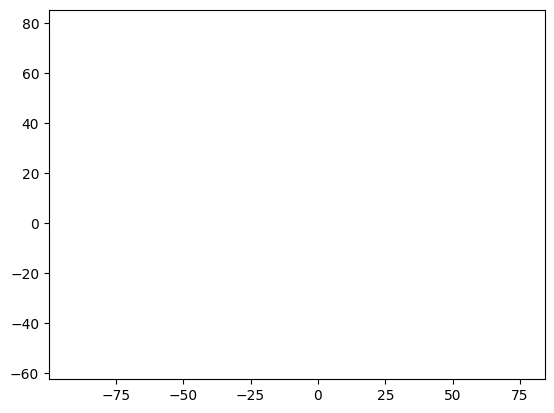

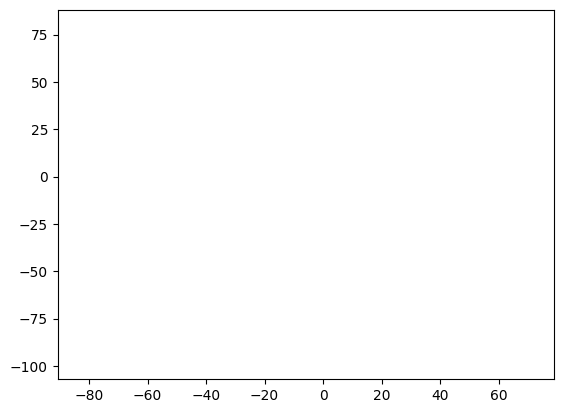

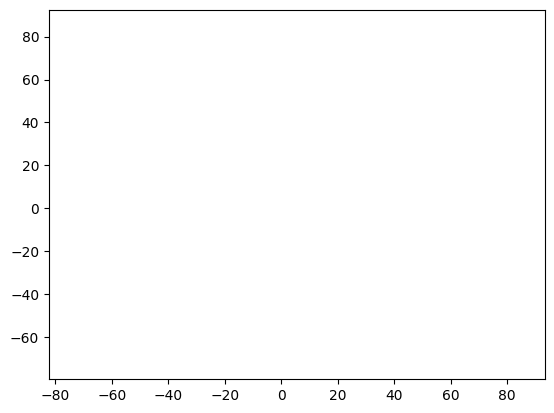

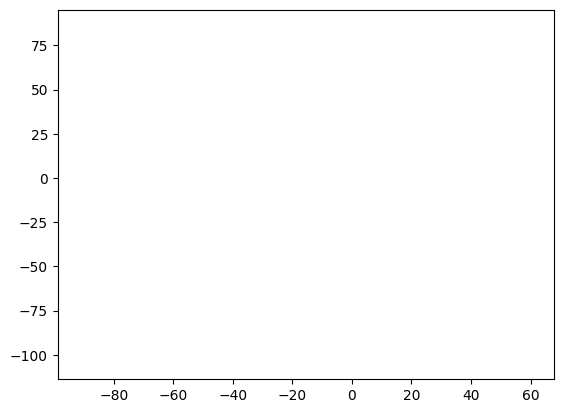

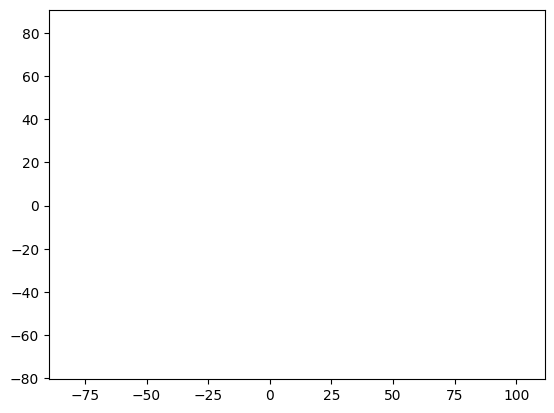

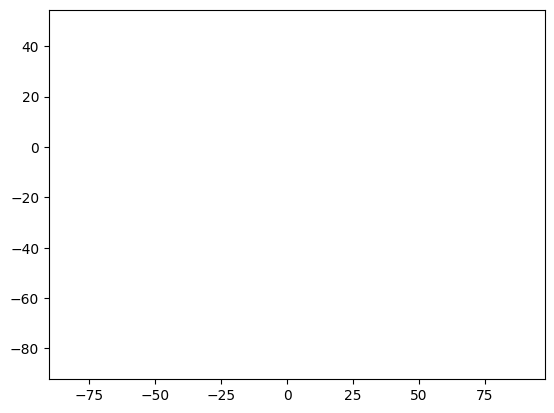

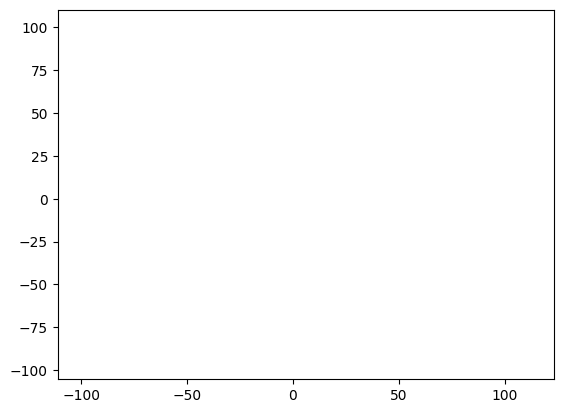

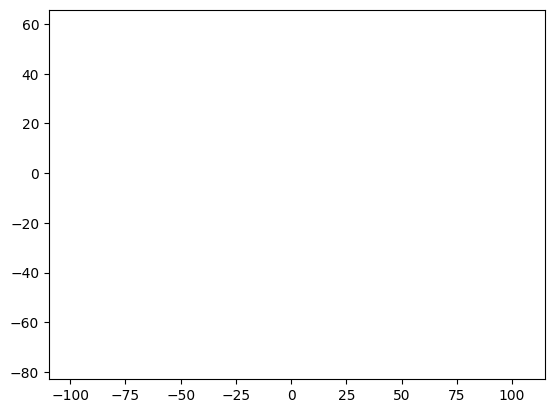

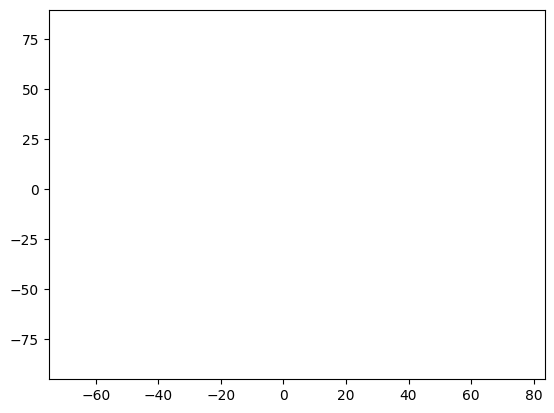

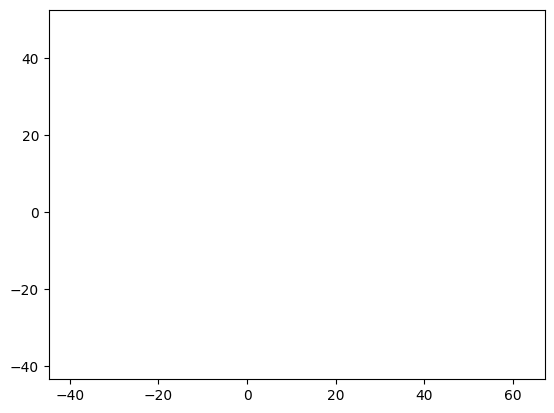

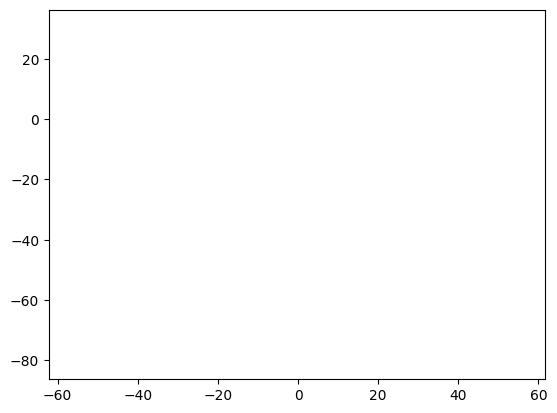

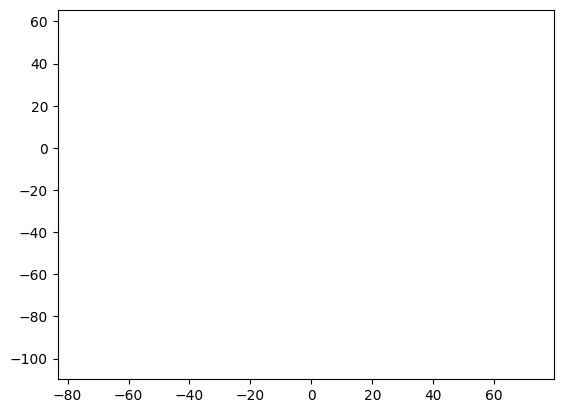

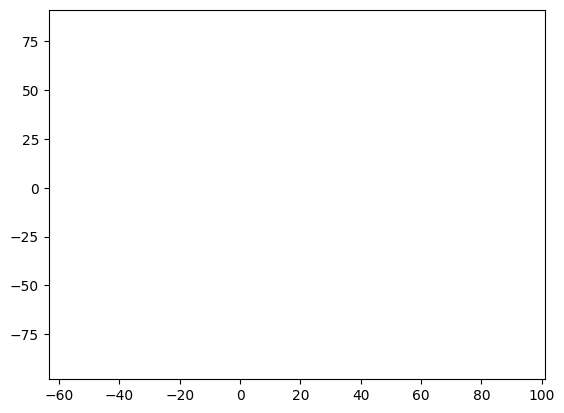

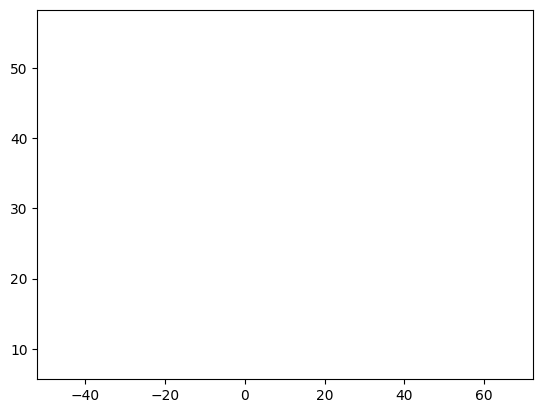

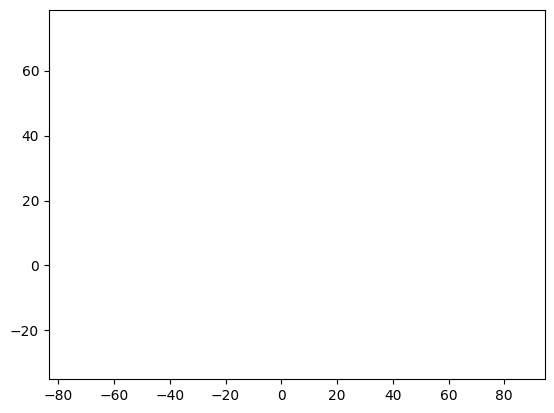

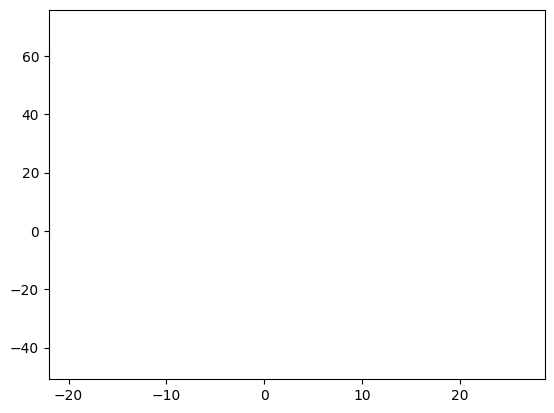

/tmp/ipykernel_2456043/3925365513.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


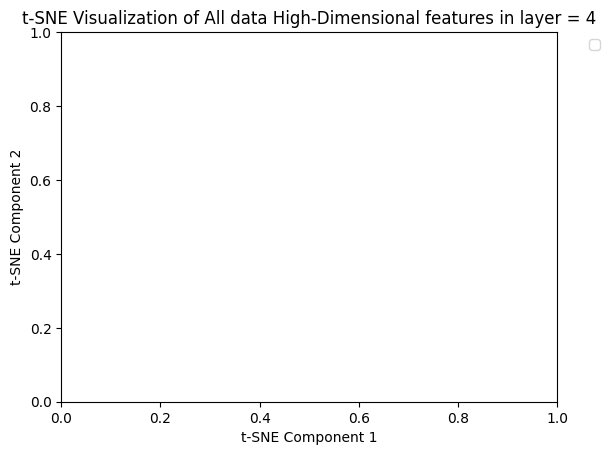

In [9]:
# Assuming df is your DataFrame and it has been defined earlier
data = df[['feature1', 'feature2']].to_pandas().values   
labels = df['labels'].to_pandas().values   

plt.figure(figsize=(10, 8))

# Define vibrant colors for labels 0-9
vibrant_colors = [
    '#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF', '#00FFFF', 
    '#FFA500', '#800080', '#008000', '#000080'
]

# Create a colormap for unique colors for each label
color_mapping = {
    '10-19': 'blue',    # Single color for labels 10-19
    '0-9': vibrant_colors,  # List of vibrant colors for labels 0-9
    '100-109': 'red'    # Single color for labels 100-109
}

# Define alpha mapping for each label range
alpha_mapping = {
    '10-19': np.linspace(0.0, 0.0, 10),  # 10 alpha values for labels 10-19
    '0-9': np.linspace(0.8, 0.8, 10),    # 10 alpha values for labels 0-9
    '100-109': np.linspace(0.0,0.0, 10) # 10 alpha values for labels 100-109
}

# Plot each label with its specific color and alpha value
for label in np.unique(labels):
    mask = labels == label
    
    # Determine which range the label belongs to
    if 10 <= label <= 19:
        color = color_mapping['10-19']
        alpha = alpha_mapping['10-19'][label - 10]  # Get alpha value for this label
    elif 0 <= label <= 9:
        color = color_mapping['0-9'][label]  # Get vibrant color for this label
        alpha = alpha_mapping['0-9'][label]  # Get alpha value for this label
    elif 100 <= label <= 109:
        color = color_mapping['100-109']
        alpha = alpha_mapping['100-109'][label - 100]  # Get alpha value for this label
    else:
        continue  # Skip labels outside the specified ranges
    
    plt.scatter(
        data[mask, 0], 
        data[mask, 1], 
        c=color,  
        alpha=alpha,  # Specific alpha for the label
        label=f'Label {label}'
    )
    plt.show()

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.title(f't-SNE Visualization of All data High-Dimensional features in layer = {index}')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
# plt.xlim(1.15e-5,1.25e-5)
# plt.ylim(0.7e-5,0.9e-5)

plt.show()

In [ ]:

import torch
import matplotlib.pyplot as plt
from cuml.decomposition import PCA
from cuml.manifold import TSNE


# Assume `model` is your ResNet instance and `train_loader` is your DataLoader with 100 samples from 10 classes.

# Initialize storage for features and labels
features_0 = []
labels = []
layer_index = 4
# Extract features from layer 1
model.eval()
loaders = [test_loader, pgd_test_loader,fgsm_test_loader, Autoattack_test_loader,svhn_test_loader,isun_test_loader,lsun_test_loader]
with torch.no_grad():
    for loader in loaders:
        for inputs, targets in loader:
            inputs = inputs.cuda() 
            # if loader != test_loader:
            #     targets += 10
            layer1_features = model.intermediate_forward(inputs, layer_index=layer_index)
            layer1_features_flat = layer1_features.view(layer1_features.size(0), -1)
            features_0.append(layer1_features_flat.cpu())
            labels.append(targets.cpu())
            if len(labels) > 15000:
                break
        

# Concatenate all features and labels
features_0 = torch.cat(features_0, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()

# # PCA and t-SNE feature reduction
# pca = PCA(n_components=2)
# pca_features = pca.fit_transform(features_0)

tsne = TSNE(n_components=2, perplexity=50, random_state=0)
tsne_features = tsne.fit_transform(features_0)

# Plotting all features together
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# # PCA Plot
# axes[1].scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
# axes[1].set_title("t-SNE Feature Visualization")
# axes[1].set_xlabel("Dimension 1")
# axes[1].set_ylabel("Dimension 2")


# t-SNE Plot
axes[1].scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[1].set_title("t-SNE Feature Visualization")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")

plt.tight_layout()
plt.show()




/home/local/ASUAD/asing651/.conda/envs/rapids_env/lib/python3.10/site-packages/cuml/internals/api_decorators.py:382: UserWarning: Starting from version 22.04, the default method of TSNE is 'fft'.
  return init_func(self, *args, **filtered_kwargs)


MemoryError: std::bad_alloc: out_of_memory: CUDA error at: /tmp/pip-build-env-z8x7r21l/normal/lib/python3.12/site-packages/librmm/include/rmm/mr/device/cuda_memory_resource.hpp:62: cudaErrorMemoryAllocation out of memory

In [7]:
len(features_0)

1507

In [ ]:

from sklearn.preprocessing import StandardScaler
gmm_scores = {}
for data in test_loaders:
   gmm_scores[data] = {}
   for layer_index in loaded_features_dict['ID_Train'].keys():
      gmm =  gmm_final['ID_Train'][layer_index]
   #    print(loaded_features_dict[data][layer_index])
      feature_values = loaded_features_dict['ID_Train'][layer_index]['features']
      print(data," -... ")
      feature_values =  umap_model.transform(feature_values) 
      print("converted to lower dimenion")
      print(feature_values[0].shape)
      gmm_scores[data][layer_index] = gmm.score_samples(feature_values)
      print(f"score generated for {layer_index}, for data = {data}")





        

In [ ]:
import pandas as pd
rows = []
for data_type, layers in gmm_scores.items():
    for i in range(len(next(iter(layers.values())))):  # Assumes all layers have the same length
        row = [data_type]
        for layer_index in range(5):  # Assuming 5 layer indices
            row.append(layers[layer_index][i])
        rows.append(row)

# Create DataFrame
headers = ["data_type", "layer_index1", "layer_index2", "layer_index3", "layer_index4", "layer_index5"]
df = pd.DataFrame(rows, columns=headers)
df.to_csv("gmm_scores9thdec.csv", index=False)
# Display the DataFrame
print(df)

In [ ]:

import pandas as pd 
id_df = df[df['data_type'] == 'ID'] 
thresholds = {}
layer_columns = ["layer_index1", "layer_index2", "layer_index3", "layer_index4", "layer_index5"]
for col in layer_columns:
    threshold = id_df[col].quantile(0.05)  # 5th percentile
    thresholds[col] = threshold

print("Thresholds for 95% TPR:")
for layer, thresh in thresholds.items():
    print(f"{layer}: {thresh}")


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

def compute_metrics_for_data_type(df, thresholds, test_data_type):
    """
    Computes Accuracy, AUROC, AUPR for each layer and adds a column counting
    the number of layers that correctly classified each sample.

    Parameters:
    - df (pd.DataFrame): The dataset containing 'data_type' and layer scores.
    - thresholds (dict): Dictionary with layer names as keys and threshold values as values.
    - test_data_type (str): The specific OOD data type to evaluate against 'ID'.

    Returns:
    - metrics_result (dict): Dictionary containing metrics for each layer.
    - subset (pd.DataFrame): The subset DataFrame with the new 'correct_layer_count' column.
    """
    # Filter for ID and the test_data_type
    subset = df[(df['data_type'] == 'ID') | (df['data_type'] == test_data_type)].copy()
    
    # Create binary ground truth: 1 for ID, 0 for non-ID
    y_true = (subset['data_type'] == 'ID').astype(int)
    
    metrics_result = {}
    
    # Initialize a DataFrame to store binary predictions for each layer
    predictions = pd.DataFrame(index=subset.index)
    
    for layer_col, threshold in thresholds.items():
        # Extract scores for this layer
        y_scores = subset[layer_col].values
        
        # Binary predictions based on threshold
        y_pred = (y_scores >= threshold).astype(int)
        
        # Store predictions in the DataFrame
        predictions[layer_col] = y_pred
        
        
        acc = accuracy_score(y_true, y_pred)

        # Compute AUROC
        try:
            auroc = roc_auc_score(y_true, y_scores)
        except ValueError:
            auroc = float('nan')
        
        # Compute AUPR
        try:
            aupr = average_precision_score(y_true, y_scores)
        except ValueError:
            aupr = float('nan')
        
        # Store metrics for this layer
        metrics_result[layer_col] = {
            'accuracy': acc,
            'auroc': auroc,
            'aupr': aupr
        }
    correct_predictions = predictions.eq(y_true, axis=0)  # DataFrame of booleans
    subset['correct_layer_count'] = correct_predictions.sum(axis=1)
    
    return metrics_result, subset

# Example usage:
# Assume we have a DataFrame 'df' and a dictionary 'thresholds' defined elsewhere
# Replace 'OOD' with whatever non-ID data_type you want to evaluate
test_data_types = ['SVHN','iSUN','LSUN','AutoAttack','PGD','FGSM','ID']

# Initialize a dictionary to store all metrics for each test_data_type
all_metrics = {}

for d_type in test_data_types:
    metrics_for_ood, subset_with_counts = compute_metrics_for_data_type(df, thresholds, d_type)
    all_metrics[d_type] = metrics_for_ood
    print(f"\nData Type: {d_type}")
    for layer, vals in metrics_for_ood.items():
        print(f"{layer} vs ID:")
        print(f"  Accuracy: {vals['accuracy']:.4f}  ,  AUROC: {vals['auroc']:.4f}  ,  AUPR: {vals['aupr']:.4f}")
    


df.loc[subset_with_counts.index, 'correct_layer_count_' + d_type] = subset_with_counts['correct_layer_count']

# After the loop, 'df' will have new columns like 'correct_layer_count_SVHN', etc.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Assuming 'df' is your DataFrame
df_long = df.melt(id_vars='data_type', 
                  var_name='layer', 
                  value_name='score')

# List of layer columns
layers = ["layer_index1", "layer_index2", "layer_index3", "layer_index4", "layer_index5"]

for layer in layers:
    if layer == 'layer_index5':
        filtered_df = df[df[layer] >= 0.5]
    else:
        filtered_df = df
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=filtered_df, x='data_type', y=layer, hue='data_type', palette='deep', alpha=0.7)
    plt.title(f'Scatter Plot for {layer}')
    plt.xlabel('Data Type')
    plt.ylabel('Score')
    plt.legend(title='Data Type')
    plt.show()




In [ ]:
# from sklearn.manifold import TSNE
# import numpy as np

# # Define the new dictionary for t-SNE representations
# tsne_features_dict = {}

# # Set t-SNE parameters (you can adjust these as needed)
# tsne = TSNE(n_components=2, random_state=42)

# # Iterate through test loaders
# for test_loader_name, layer_data in loaded_features_dict.items():
#     tsne_features_dict[test_loader_name] = {}
    
#     for layer_index, layer_info in layer_data.items():
#         # Get features
#         features = layer_info["features"]
        
#         # Ensure features are in a compatible format (e.g., numpy array)
#         features = np.array(features)
        
#         # Compute t-SNE
#         tsne_representation = tsne.fit_transform(features)
        
#         # Save t-SNE results to the new dictionary
#         tsne_features_dict[test_loader_name][layer_index] = {
#             "tsne_representation": tsne_representation
#         }

# # Now tsne_features_dict contains t-SNE representations for each test_loader and layer_index


In [ ]:
# import torch
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE

# # Assume `model` is your ResNet instance and `train_loader` is your DataLoader with 100 samples from 10 classes.

# # Initialize storage for features and labels
# features_0 = []
# labels = []
# layer_index = 0
# # Extract features from layer 1
# model.eval()
# with torch.no_grad():
#     for inputs, targets in train_loader:
#         inputs = inputs.cuda()
#         layer1_features = model.intermediate_forward(inputs, layer_index=layer_index)
#         # Flatten the features if they are multi-dimensional (e.g., [batch, channels, height, width])
#         layer1_features_flat = layer1_features.view(layer1_features.size(0), -1)
#         features_0.append(layer1_features_flat.cpu())
#         labels.append(targets.cpu())
#         if len(labels) > 500:
#             break

# # Concatenate all features and labels
# features_0 = torch.cat(features_0, dim=0).numpy()
# labels = torch.cat(labels, dim=0).numpy()

# # PCA and t-SNE feature reduction
# pca = PCA(n_components=2)
# pca_features = pca.fit_transform(features_0)

# tsne = TSNE(n_components=2, perplexity=30, random_state=0)
# tsne_features = tsne.fit_transform(features_0)

# # Plotting all features together
# fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# # PCA Plot
# axes[0].scatter(pca_features[:, 0], pca_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
# axes[0].set_title("PCA Feature Visualization")
# axes[0].set_xlabel("Dimension 1")
# axes[0].set_ylabel("Dimension 2")

# # t-SNE Plot
# axes[1].scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
# axes[1].set_title("t-SNE Feature Visualization")
# axes[1].set_xlabel("Dimension 1")
# axes[1].set_ylabel("Dimension 2")

# plt.tight_layout()
# plt.show()




In [ ]:
# Plotting each class separately
unique_labels = sorted(set(labels))
num_classes = len(unique_labels)

# Create separate plots for each class
fig, axes = plt.subplots(num_classes, 2, figsize=(15, 5 * num_classes))
if num_classes == 1:
    axes = [axes]  # Ensure axes is iterable for a single class

for i, label in enumerate(unique_labels):
    class_mask = labels == label
    class_pca_features = pca_features[class_mask]
    class_tsne_features = tsne_features[class_mask]
    # PCA Plot for this class
    axes[i][0].scatter(class_pca_features[:, 0], class_pca_features[:, 1], cmap='tab10', alpha=0.7)
    axes[i][0].set_title(f"PCA Feature Visualization - Class {label} , layer = {layer_index}")
    axes[i][0].set_xlabel("Dimension 1")
    axes[i][0].set_ylabel("Dimension 2")

    # t-SNE Plot for this class
    axes[i][1].scatter(class_tsne_features[:, 0], class_tsne_features[:, 1], cmap='tab10', alpha=0.7)
    axes[i][1].set_title(f"t-SNE Feature Visualization - Class {label}")
    axes[i][1].set_xlabel("Dimension 1")
    axes[i][1].set_ylabel("Dimension 2")

plt.tight_layout()
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Initialize storage for OOD features from all test loaders
ood_features_dict = {}

# Helper function to extract features
def extract_features(loader, model, layer_index=0):
    features = []
    labels = []
    model.eval()
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.cuda()
            layer_features = model.intermediate_forward(inputs, layer_index=layer_index)
            layer_features_flat = layer_features.view(layer_features.size(0), -1)
            features.append(layer_features_flat.cpu())
            labels.append(targets.cpu())
        features = torch.cat(features, dim=0).numpy()
        labels = torch.cat(labels, dim=0).numpy() if len(labels) > 0 else None
    return features, labels

# Extract features for original dataset (in-distribution features)
features_id, labels_id = extract_features(train_loader, model)

# Extract OOD features from each test loader
test_loaders = {
    "PGD": pgd_test_loader,
    "FGSM": fgsm_test_loader,
    "LSUN": lsun_test_loader,
    "SVHN": DataLoader(svhn_test_dataset, batch_size=64, shuffle=False),
    "iSUN": DataLoader(isun_test_dataset, batch_size=64, shuffle=False),
}

for name, loader in test_loaders.items():
    ood_features, _ = extract_features(loader, model)
    ood_features_dict[name] = ood_features

# Dimensionality Reduction with PCA
pca = PCA(n_components=2)
pca_features_id = pca.fit_transform(features_id)
pca_features_ood_dict = {name: pca.transform(ood_features) for name, ood_features in ood_features_dict.items()}

# Dimensionality Reduction with t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
tsne_features_id = tsne.fit_transform(features_id)
tsne_features_ood_dict = {name: tsne.fit_transform(ood_features) for name, ood_features in ood_features_dict.items()}

# Plotting PCA and t-SNE visualizations
unique_classes = sorted(set(labels_id))
num_ood = len(pca_features_ood_dict)

# Creating separate grids for PCA and t-SNE
fig_pca, axes_pca = plt.subplots(len(unique_classes), num_ood, figsize=(15, 5 * len(unique_classes)))
fig_tsne, axes_tsne = plt.subplots(len(unique_classes), num_ood, figsize=(15, 5 * len(unique_classes)))

if len(unique_classes) == 1:
    axes_pca = [axes_pca]  # Ensure axes is iterable for a single class
    axes_tsne = [axes_tsne]

for i, class_label in enumerate(unique_classes):
    class_mask = labels_id == class_label
    class_features_id_pca = pca_features_id[class_mask]
    class_features_id_tsne = tsne_features_id[class_mask]

    for j, (ood_name, pca_features_ood) in enumerate(pca_features_ood_dict.items()):
        # PCA Plot
        axes_pca[i][j].scatter(class_features_id_pca[:, 0], class_features_id_pca[:, 1], alpha=0.7, label=f"Class {class_label}")
        axes_pca[i][j].scatter(pca_features_ood[:, 0], pca_features_ood[:, 1], alpha=0.7, label=f"{ood_name} (OOD)", c='red')
        axes_pca[i][j].set_title(f"PCA: Class {class_label} vs {ood_name} (OOD)")
        axes_pca[i][j].set_xlabel("PCA Dimension 1")
        axes_pca[i][j].set_ylabel("PCA Dimension 2")
        axes_pca[i][j].legend()

        # t-SNE Plot
        tsne_features_ood = tsne_features_ood_dict[ood_name]
        axes_tsne[i][j].scatter(class_features_id_tsne[:, 0], class_features_id_tsne[:, 1], alpha=0.7, label=f"Class {class_label}")
        axes_tsne[i][j].scatter(tsne_features_ood[:, 0], tsne_features_ood[:, 1], alpha=0.7, label=f"{ood_name} (OOD)", c='red')
        axes_tsne[i][j].set_title(f"t-SNE: Class {class_label} vs {ood_name} (OOD)")
        axes_tsne[i][j].set_xlabel("t-SNE Dimension 1")
        axes_tsne[i][j].set_ylabel("t-SNE Dimension 2")
        axes_tsne[i][j].legend()

plt.tight_layout()
plt.show()


In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Assume `model` is your ResNet instance and `data_loader` is your DataLoader with 100 samples from 10 classes.

# Initialize storage for features and labels
features_4 = []
labels = []
layer_index = 4
# Extract features from layer 1
model.eval()
with torch.no_grad():
    for inputs, targets in train_loader:
        inputs = inputs.cuda()
        layer1_features = model.intermediate_forward(inputs, layer_index=layer_index)
        # Flatten the features if they are multi-dimensional (e.g., [batch, channels, height, width])
        layer1_features_flat = layer1_features.view(layer1_features.size(0), -1)
        features_4.append(layer1_features_flat.cpu())
        labels.append(targets.cpu())
        if len(labels) >500:
            break

# Concatenate all features and labels
features_4 = torch.cat(features_4, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
# PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features_4)
print("PCA Dope ")
# PCA Plot
axes[0].scatter(pca_features[:, 0], pca_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[0].set_title("PCA Feature Visualization")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
tsne_features = tsne.fit_transform(features_4)




# t-SNE Plot
axes[1].scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[1].set_title("t-SNE Feature Visualization")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")

plt.colorbar(plt.cm.ScalarMappable(cmap='tab10'), ax=axes, location='right', label="Class")
plt.tight_layout()

plt.savefig("layer 4.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Assume `model` is your ResNet instance and `data_loader` is your DataLoader with 100 samples from 10 classes.

# Initialize storage for features and labels
features_3 = []
labels = []
layer_index = 3
# Extract features from layer 1
model.eval()
with torch.no_grad():
    for inputs, targets in train_loader:
        inputs = inputs.cuda()
        layer1_features = model.intermediate_forward(inputs, layer_index=layer_index)
        # Flatten the features if they are multi-dimensional (e.g., [batch, channels, height, width])
        layer1_features_flat = layer1_features.view(layer1_features.size(0), -1)
        features_3.append(layer1_features_flat.cpu())
        labels.append(targets.cpu())
        if len(labels) >500:
            break

# Concatenate all features and labels
features_3 = torch.cat(features_3, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
# PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features_3)
print("PCA Dope ")
# PCA Plot
axes[0].scatter(pca_features[:, 0], pca_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[0].set_title("PCA Feature Visualization layer 3")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
tsne_features = tsne.fit_transform(features_3)




# t-SNE Plot
axes[1].scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[1].set_title("t-SNE Feature Visualization layer 3")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")

plt.colorbar(plt.cm.ScalarMappable(cmap='tab10'), ax=axes, location='right', label="Class")
plt.tight_layout()

plt.savefig("layer 3.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Assume `model` is your ResNet instance and `data_loader` is your DataLoader with 100 samples from 10 classes.

# Initialize storage for features and labels
features_2 = []
labels = []
layer_index = 2
# Extract features from layer 1
model.eval()
with torch.no_grad():
    for inputs, targets in train_loader:
        inputs = inputs.cuda()
        layer1_features = model.intermediate_forward(inputs, layer_index=layer_index)
        # Flatten the features if they are multi-dimensional (e.g., [batch, channels, height, width])
        layer1_features_flat = layer1_features.view(layer1_features.size(0), -1)
        features_2.append(layer1_features_flat.cpu())
        labels.append(targets.cpu())
        if len(labels) >500:
            break

# Concatenate all features and labels
features_2 = torch.cat(features_2, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
# PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features_2)
print("PCA Dope ")
# PCA Plot
axes[0].scatter(pca_features[:, 0], pca_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[0].set_title("PCA Feature Visualization layer 2")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
tsne_features = tsne.fit_transform(features_2)




# t-SNE Plot
axes[1].scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[1].set_title("t-SNE Feature Visualization layer 2")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")

plt.colorbar(plt.cm.ScalarMappable(cmap='tab10'), ax=axes, location='right', label="Class")
plt.tight_layout()

plt.savefig("layer 2.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Assume `model` is your ResNet instance and `data_loader` is your DataLoader with 100 samples from 10 classes.

# Initialize storage for features and labels
features_1 = []
labels = []
layer_index = 1
# Extract features from layer 1
model.eval()
with torch.no_grad():
    for inputs, targets in train_loader:
        inputs = inputs.cuda()
        layer1_features = model.intermediate_forward(inputs, layer_index=layer_index)
        # Flatten the features if they are multi-dimensional (e.g., [batch, channels, height, width])
        layer1_features_flat = layer1_features.view(layer1_features.size(0), -1)
        features_1.append(layer1_features_flat.cpu())
        labels.append(targets.cpu())
        if len(labels) >500:
            break

# Concatenate all features and labels
features_1 = torch.cat(features_1, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
# PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features_1)
print("PCA Dope ")
# PCA Plot
axes[0].scatter(pca_features[:, 0], pca_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[0].set_title("PCA Feature Visualization layer 1")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=0)
tsne_features = tsne.fit_transform(features_1)




# t-SNE Plot
axes[1].scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
axes[1].set_title("t-SNE Feature Visualization layer 1")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")

plt.colorbar(plt.cm.ScalarMappable(cmap='tab10'), ax=axes, location='right', label="Class")
plt.tight_layout()

plt.savefig("layer 1.png", dpi=300, bbox_inches='tight')

plt.show()